# Federated Learning con Flower: malaria (Parasitized/Uninfected)

Notebook per addestrare un modello in **federated learning** con [Flower (`flwr`)](https://flower.ai), simulando:

- **Eterogeneita dei dati (non-IID)** tra i client tramite il `DirichletPartitioner` di `flwr-datasets`, controllata dal parametro **`alpha`**.
- **Aggregazione con `FedProx`** (`flwr.serverapp.strategy.FedProx`), con il coefficiente del termine prossimale **`mu`** configurabile (`mu=0.0` equivale a `FedAvg`).
- **Differential Privacy** tramite **DP-SGD record-level lato client** (Opacus `PrivacyEngine`), con budget di privacy **`epsilon`** target configurabile.

Dataset: "Cell Images for Detecting Malaria" (Kaggle, `iarunava/cell-images-for-detecting-malaria`), scaricato in locale dentro `cell_images/` e pre-ridimensionato a 32x32 in `cell_images_32/` dallo script `resize_dataset.py`.

## Che tipo di garanzia di privacy fornisce questo notebook

L'unita' di privacy e' il **singolo campione** (record-level DP, come in Abadi et al. 2016): la garanzia risponde alla domanda *"l'immagine di questo paziente ha influenzato il modello finale?"*.

Il meccanismo e' **interamente lato client**: dentro il training locale, Opacus clippa il gradiente di **ogni singolo campione** alla norma `max_grad_norm` e aggiunge rumore gaussiano prima dell'update. I pesi che il client rimanda al server sono quindi **gia' perturbati**: il server non vede mai un update non rumoroso, il che soddisfa il modello di minaccia *honest-but-curious* senza richiedere secure aggregation.

Il `noise_multiplier` viene calcolato da Opacus stesso (`make_private_with_epsilon`) a partire dall'epsilon target, dal `sample_rate = batch_size / n_campioni_del_client` e dal numero totale di step del client sull'**intero training federato** (`num_rounds * local_epochs` epoche locali). L'epsilon riportato e' quindi il **budget totale per client**, non per round.

Poiche' le partizioni Dirichlet hanno dimensioni diverse, ogni client ha un proprio `sample_rate` e quindi un proprio `noise_multiplier`: tutti spendono lo stesso epsilon, ciascuno calibrato sul proprio dataset.

### Perche' non la DP client-level di Flower

Una versione precedente di questo notebook usava i wrapper DP di Flower (`DifferentialPrivacyServerSideFixedClipping`), cioe' DP **client-level**: si clippa l'intero update di un client e si aggiunge rumore all'aggregato. Quello schema e' stato abbandonato per due motivi:

1. **Garanzia diversa da quella descritta nella tesi**: risponde a *"questo ospedale ha partecipato?"*, non *"questo paziente e' nei dati?"*.
2. **Regime degenere con pochi client**: il rumore viene mediato solo su `num_sampled_clients`, e con `fraction_train = 1.0` su 6 client il `sample_rate` dell'accounting vale 1.0, quindi **non c'e' amplificazione da campionamento**. Con ~100k parametri il rapporto rumore/segnale restava sopra 10x persino a epsilon = 512. DP-FedAvg (McMahan et al.) e' pensato per centinaia o migliaia di client per round.

Con DP-SGD record-level il rumore e' invece mediato sul batch e ammortizzato su migliaia di step di SGD, e gli epsilon utili tornano nell'ordine di grandezza usato in letteratura.

## Nota su FedProx e sul termine prossimale

`FedProx` e' identico a `FedAvg` lato aggregazione server; l'unica differenza e' che ad ogni round il valore di `proximal_mu` viene inviato ai client nel `ConfigRecord` (chiave `"proximal-mu"`), e ogni client aggiunge al proprio objective locale il termine `(mu/2) * ||w_locali - w_globali||^2`.

Qui il termine prossimale e' applicato come **step separato dopo `optimizer.step()`** invece che sommato alla loss: vedi la docstring di `train()` per il perche' (in breve: sotto DP il `DPOptimizer` sovrascrive `p.grad`, e il termine prossimale non dipende dai dati quindi non deve consumare budget di privacy).


## 1. Installazione dipendenze

Da eseguire una sola volta (o ogni volta che cambi ambiente/kernel).

In [1]:
# %pip install -q "flwr[simulation]" "flwr-datasets[vision]" torch torchvision opacus matplotlib pandas


In [2]:
import random
from dataclasses import dataclass, field, asdict
from typing import Optional

import numpy as np
import torch

import matplotlib.pyplot as plt
import pandas as pd


## 2. Configurazione

Tutti i parametri dell'esperimento in un unico posto.

Lo sweep e' su **tre dimensioni annidate**: `seeds` (esterno) -> `alphas` -> `target_epsilons`
(interno). L'ordine e' scelto apposta per una run non presidiata: se lo sweep si interrompe,
i seed gia' completati sono completi su tutte le alpha, invece di avere tutti i seed a meta'.

### Iperparametri rivisti per DP-SGD

`batch_size` e `local_epochs` sono stati alzati rispetto alla versione client-level
(32 / 1 -> 128 / 2). Sotto DP-SGD il batch ha due effetti opposti: aumentarlo riduce il
rumore relativo (il rumore gaussiano si media su piu' campioni) ma alza anche
`sample_rate = batch/N`, riducendo l'amplificazione da campionamento e costringendo
l'accountant ad alzare sigma. Il netto e' che il rapporto rumore/segnale scala come
**1/sqrt(batch)**. Con N ~ 2.900 campioni per client e 50 round, a epsilon = 8:

| batch | step/round | step totali | rumore/segnale |
|---|---|---|---|
| 32 | 92 | 4.600 | 8.0x |
| 64 | 46 | 2.300 | 4.8x |
| **128** | 23 | 1.150 | **3.0x** |
| 256 | 12 | 600 | 2.0x |

Il prezzo del batch grande e' il crollo del numero di passi di SGD. Con `local_epochs = 1`
restano 23 step per round, 1.150 totali, cioe' **50 epoche effettive** sui dati di ogni
client: abbondanti per una CNN da ~100k parametri su un compito binario 32x32.

Alzare `local_epochs` a 2 raddoppierebbe gli step (2.300) ma anche il tempo di calcolo, e
soprattutto **peggiorerebbe il rumore**: piu' step significano piu' composizione, quindi
l'accountant deve alzare sigma (1.200 -> 1.529 a epsilon = 8, cioe' rumore/segnale da 3.0x
a 3.8x). `local_epochs = 1` e' quindi migliore sia sul tempo sia sulla privacy, e paga solo
in budget di ottimizzazione.

Vale la pena tagliare le epoche locali e **non** i round: il protocollo di riporto (media
degli ultimi 10 round, vedi sezione 8) su 50 round usa l'ultimo 20% del training, mentre su
30 round userebbe l'ultimo 33%, pescando round in cui il modello sta ancora migliorando.

Il `learning_rate` sale da 0.01 a 0.03 per accompagnare il batch piu' grande.

`min_partition_size` passa da 10 a 1000: alle alpha basse il partizionatore Dirichlet puo'
produrre client molto piccoli, e con batch 128 un client da poche decine di campioni
darebbe `sample_rate` vicino o superiore a 1, rompendo l'accounting di privacy.


In [3]:
@dataclass
class ExperimentConfig:
    # --- Federated setup ---
    num_clients: int = 6               # numero totale di client simulati (SuperNode)
    # 100 e non 50: nelle diagnostiche D1, D2 e D5 il massimo cadeva sull'ULTIMO round,
    # cioe' nessuna run aveva convergito entro 50 round. A alpha=0.5 la seed 43 ha avuto
    # bisogno di ~180 round per arrivare a 0.951 (ma con il vecchio ottimizzatore).
    num_rounds: int = 100
    fraction_train: float = 1.0        # frazione di client campionati per il training ad ogni round
    fraction_evaluate: float = 1.0     # frazione di client campionati per la evaluation locale
    min_available_clients: int = 2

    # --- Iperparametri locali (client-side) ---
    local_epochs: int = 1
    batch_size: int = 128
    learning_rate: float = 0.03

    # momentum = 0.0, ed e' la modifica che sblocca gli alpha bassi.
    # Con m=0.9 la combinazione (alpha=0.5, seed=42) era MORTA: loss bloccata su ln2 per
    # 200 round, accuracy mai sopra 0.5. Il test in test_ottimizzatore.ipynb ha isolato la
    # causa: non e' la dimensione del passo. Due configurazioni con lo STESSO passo
    # effettivo lr/(1-m) = 0.03 danno esiti opposti -- lr=0.003 con m=0.9 resta a 0.500,
    # lr=0.03 con m=0.0 arriva a 0.703 -- quindi il problema e' l'accumulo in se'.
    # Motivo: un client quasi mono-classe produce gradienti tutti coerenti, il momentum li
    # amplifica (fino a 10x con m=0.9), il modello locale scappa lontano dai pesi globali e
    # la media di sei modelli scappati in direzioni diverse e' un predittore costante.
    # Costo della modifica dove le cose gia' funzionavano: a alpha=10 si passa da 0.961 a
    # 0.952, un punto. Guadagno a alpha=0.5 seed 42: da 0.500 (morta) a 0.703.
    momentum: float = 0.0

    # --- Aggregazione: FedProx ---
    fedprox_mu: float = 0.01           # peso del termine prossimale. 0.0 => equivalente a FedAvg

    # --- Eterogeneita dei dati (Dirichlet partitioning) ---
    alphas: list = field(default_factory=lambda: [0.4])
    # alpha = 10 e non 100 come ancora
    #   near-IID: a 10 la purezza media di classe per client e' 58,1% contro il 50% del caso
    #   IID puro, quindi in tesi va descritto come "mildly non-IID", non come baseline IID.
    #   In compenso la griglia e' meglio spaziata in eterogeneita' realizzata: i salti di
    #   purezza diventano 15,7 / 6,9 / 8,4 punti invece di 21,2 / 6,9 / 8,4.
    # alpha = 0.2 e non 0.1: a 0.1 la probabilita' che un singolo draw rispetti
    #   min_partition_size=500 e' ~1.8%, e le partizioni che sopravvivono al vincolo
    #   assomigliano comunque a quelle di 0.2 (rapporto 11,3x contro 10,5x).
    min_partition_size: int = 500
    # Pavimento sulla dimensione della partizione: con lo split 80/20 interno al client
    # garantisce n_train >= 400, quindi sample rate q = 128/400 = 0.32 < 1. Limita lo
    # quantity skew ma non lo elimina: a alpha=0.2 il rapporto mediano fra client piu'
    # grande e piu' piccolo resta ~11:1.
    partition_max_retries: int = 50    # retry esterno al DirichletPartitioner

    # --- Seed: draw Dirichlet indipendenti allo stesso alpha ---
    # Due e non tre: vincolo di tempo di calcolo, da dichiarare fra i limiti. Nota che la
    # simulazione non e' bit-riproducibile (gli attori Ray e il generatore di Opacus non
    # vengono riseminati), quindi le medie sui seed vanno lette come stime con varianza.
    seeds: list = field(default_factory=lambda: [42, 43, 44])

    # --- Differential Privacy: DP-SGD record-level lato client (Opacus) ---
    dp_enabled: bool = True
    run_baseline: bool = True          # run senza DP (epsilon = inf), riferimento
    # Griglia rivista dopo il primo sweep. Tolto 16 perche' ridondante: a alpha=10 gli
    # epsilon 8/16/32 davano 0.922/0.925/0.930, tre run per 0.8 punti. Aggiunto 0.5 perche'
    # il tratto piu' ripido della curva era fra 1 e 2 (0.751 -> 0.849), quindi il punto di
    # rottura della privacy sta piu' in basso e non era mai stato sfiorato.
    target_epsilons: list = field(default_factory=lambda: [0.5, 1, 2, 4, 8])
    target_delta: float = 1e-5         # delta << 1 / n_campioni_del_client

    # max_grad_norm = 5.0, ed e' l'altra modifica che conta.
    # Con C=1.0 il clipping, non il rumore, era il fattore limitante: a alpha=1 seed 42 la
    # run con epsilon=1000 (rumore trascurabile) restava a 0.623, mentre epsilon=32 con C=5
    # arrivava a 0.908. Trenta volte meno budget di privacy e 0.28 di accuracy in piu'.
    # C NON e' un parametro di privacy: e' il bound di sensibilita', e sigma scala con lui,
    # quindi (epsilon, delta) restano esattamente quelli dichiarati.
    max_grad_norm: float = 5.0

    # --- Esecuzione ---
    skip_completed: bool = True        # salta le combinazioni gia' presenti su disco (ripresa)
    max_hours: float = 0.0             # METTI LE ORE CHE HAI: lo sweep si ferma pulito dopo
                                       # N ore e riprende al rilancio. Il ciclo e' ordinato
                                       # seed -> alpha -> epsilon, quindi si interrompe
                                       # lasciando seed interi invece che tutti a meta'.

    client_resources: dict = field(default_factory=lambda: {"num_cpus": 2, "num_gpus": 0.0})


CONFIG = ExperimentConfig()

# Guardia sull'accounting DP. Il batch deve restare ben sotto la dimensione di TRAINING del
# client piu' piccolo (min_partition_size meno lo split 80/20 interno), altrimenti il sample
# rate q = batch / n_train si avvicina a 1, l'amplificazione da subsampling sparisce e sigma
# esplode. Il fattore 0.5 mantiene q <= 0.5 anche nel caso peggiore.
_MIN_CLIENT_TRAIN = int(CONFIG.min_partition_size * 0.8)
assert CONFIG.batch_size <= 0.5 * _MIN_CLIENT_TRAIN, (
    f"batch_size={CONFIG.batch_size} troppo grande per min_partition_size="
    f"{CONFIG.min_partition_size}: il client piu' piccolo avrebbe n_train={_MIN_CLIENT_TRAIN} "
    f"e q={CONFIG.batch_size / _MIN_CLIENT_TRAIN:.2f}. Abbassa il batch o alza la soglia."
)

# Client campionati per round: usato SOLO dalla strategia FedProx. Non entra nell'accounting
# di privacy: con DP-SGD record-level il budget dipende dal sample_rate dei BATCH.
CONFIG_num_sampled_clients = max(
    CONFIG.min_available_clients,
    round(CONFIG.fraction_train * CONFIG.num_clients),
)


def set_seeds(seed: int) -> None:
    """Reimposta gli RNG del processo principale. NON risemina gli attori Ray ne' il
    generatore di rumore di Opacus: le run non sono bit-riproducibili, e questo va
    dichiarato fra i limiti in Methodology."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seeds(CONFIG.seeds[0])

_n_eps = (1 if CONFIG.run_baseline else 0) + (len(CONFIG.target_epsilons) if CONFIG.dp_enabled else 0)
_n_runs = len(CONFIG.seeds) * len(CONFIG.alphas) * _n_eps
print(asdict(CONFIG))
print("client campionati per round (train):", CONFIG_num_sampled_clients)
print(f"run pianificate: {len(CONFIG.seeds)} seed x {len(CONFIG.alphas)} alpha x {_n_eps} "
      f"configurazioni di privacy = {_n_runs}")
print(f"sample rate DP nel caso peggiore: q = {CONFIG.batch_size}/{_MIN_CLIENT_TRAIN} "
      f"= {CONFIG.batch_size / _MIN_CLIENT_TRAIN:.3f}")
print(f"stima grossolana: ~18 min a run da {CONFIG.num_rounds} round => "
      f"~{_n_runs * 18 / 60:.0f} h in totale (le run senza DP sono piu' rapide)")

{'num_clients': 6, 'num_rounds': 100, 'fraction_train': 1.0, 'fraction_evaluate': 1.0, 'min_available_clients': 2, 'local_epochs': 1, 'batch_size': 128, 'learning_rate': 0.03, 'momentum': 0.0, 'fedprox_mu': 0.01, 'alphas': [0.4], 'min_partition_size': 500, 'partition_max_retries': 50, 'seeds': [42, 43, 44], 'dp_enabled': True, 'run_baseline': True, 'target_epsilons': [0.5, 1, 2, 4, 8], 'target_delta': 1e-05, 'max_grad_norm': 5.0, 'skip_completed': True, 'max_hours': 0.0, 'client_resources': {'num_cpus': 2, 'num_gpus': 0.0}}
client campionati per round (train): 6
run pianificate: 3 seed x 1 alpha x 6 configurazioni di privacy = 18
sample rate DP nel caso peggiore: q = 128/400 = 0.320
stima grossolana: ~18 min a run da 100 round => ~5 h in totale (le run senza DP sono piu' rapide)


## 3. Dati: dataset malaria (Parasitized/Uninfected) + partizionamento Dirichlet

Il dataset e' gia' binario (due sottocartelle `Parasitized/` e `Uninfected/`, una per classe): nessuna rimappatura di label necessaria, a differenza di CIFAR-10 in `pneumonia.ipynb`.

Non ha uno split train/test predefinito: lo creiamo noi (80/20, stratificato per label) prima del partizionamento — il test set resta centralizzato e non viene mai visto dai client; il train set viene distribuito tra i client con `DirichletPartitioner` di `flwr-datasets`, come nel resto della pipeline.

Le immagini sono **32x32** gia' su disco (cartella `cell_images_32/` prodotta da `resize_dataset.py`) e vengono decodificate in tensori **una volta sola** all'avvio di ogni client (sezione 4), non a ogni round.


In [4]:
import glob
import os

CELL_IMAGES_BASE_DIR = "cell_images_32"  # cartella del dataset (contiene Parasitized/ e Uninfected/).
                                          # Di default si usa la copia gia' ridimensionata a 32x32 generata da
                                          # `python resize_dataset.py`: evita di ridimensionare le immagini a
                                          # ogni accesso durante il training (dataset ~9x piu' leggero da leggere).
                                          # Se la cartella non esiste si torna automaticamente all'originale.


def find_cell_images_dir(base_dir: str) -> str:
    """Trova la cartella che contiene direttamente le sottocartelle Parasitized/ e Uninfected/.
    Il dataset Kaggle a volte ha una struttura annidata (es. cell_images/cell_images/...);
    questa funzione cerca tutte le occorrenze e sceglie quella con piu' immagini."""
    candidates = []
    for parasitized_path in glob.glob(os.path.join(base_dir, "**", "Parasitized"), recursive=True):
        candidate_dir = os.path.dirname(parasitized_path)
        if os.path.isdir(os.path.join(candidate_dir, "Uninfected")):
            n_parasitized = len(os.listdir(parasitized_path))
            candidates.append((n_parasitized, candidate_dir))
    if not candidates:
        raise FileNotFoundError(
            f"Non ho trovato sottocartelle 'Parasitized' e 'Uninfected' sotto '{base_dir}'. "
            "Esegui prima download_dataset.ipynb, oppure correggi CELL_IMAGES_BASE_DIR."
        )
    candidates.sort(reverse=True)
    for count, cand_dir in candidates:
        print(f"trovata candidata: {cand_dir}  (Parasitized: {count} immagini)")
    best_count, best_dir = candidates[0]
    print(f"uso: {best_dir}")
    return best_dir


if not os.path.isdir(CELL_IMAGES_BASE_DIR):
    print(f"'{CELL_IMAGES_BASE_DIR}' non trovata: uso 'cell_images' (immagini a piena risoluzione, "
          "caricamento piu' lento). Lancia `python resize_dataset.py` per generare la versione ridotta.")
    CELL_IMAGES_BASE_DIR = "cell_images"

CELL_IMAGES_DIR = find_cell_images_dir(CELL_IMAGES_BASE_DIR)


trovata candidata: cell_images_32  (Parasitized: 13779 immagini)
uso: cell_images_32


In [5]:
from datasets import DatasetDict
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import DirichletPartitioner


def _make_split_fn(seed: int):
    """imagefolder produce solo lo split 'train': ne ricaviamo un test set centralizzato
    (20%, stratificato per label), mai visto dai client. Lo split dipende dal seed, quindi
    seed diversi danno anche test set diversi."""
    def split_train_test(dataset_dict: DatasetDict) -> DatasetDict:
        full = dataset_dict["train"].rename_column("image", "img")
        split = full.train_test_split(test_size=0.2, seed=seed, stratify_by_column="label")
        return DatasetDict({"train": split["train"], "test": split["test"]})
    return split_train_test


# Un solo (alpha, seed) alla volta resta in memoria: i tensori decodificati di tutto il
# dataset pesano ~270 MB, quindi tenerne in cache una copia per ogni combinazione dello
# sweep esaurirebbe la RAM. Cambiando combinazione le cache vengono svuotate.
_FDS_CACHE: dict = {}
# Definite qui e non nella sezione 4 perche' get_fds() le svuota al cambio di
# combinazione, e viene chiamata gia' da questa cella e dalla visualizzazione.
_CLIENT_CACHE: dict = {}   # (alpha, seed, partition_id, batch_size) -> (trainloader, valloader)
_TESTSET_CACHE: dict = {}  # (alpha, seed, batch_size) -> testloader
_PARTITIONER_CACHE: dict = {}
# (alpha, seed) -> indice (0-based) del tentativo di draw che ha soddisfatto il vincolo di
# dimensione minima. Non viene svuotata al cambio di combinazione: e' metadato leggero e
# serve al preflight per riassumere quanto si e' lavorato vicino al limite di tentativi.
_PARTITION_ATTEMPTS: dict = {}
_ACTIVE_KEY = None


def get_fds(alpha: float, seed: int):
    """FederatedDataset partizionato con Dirichlet(alpha), draw determinato da `seed`.

    Chiamabile sia dal ServerApp sia dai client: ogni processo Ray costruisce la propria
    copia una volta sola. Passare alpha/seed esplicitamente (invece di leggerli da una
    global) evita di dipendere da come Ray propaga lo stato globale tra i processi.
    """
    global _ACTIVE_KEY
    key = (alpha, seed)
    if _ACTIVE_KEY is not None and _ACTIVE_KEY != key:
        _FDS_CACHE.clear()
        _PARTITIONER_CACHE.clear()
        _CLIENT_CACHE.clear()
        _TESTSET_CACHE.clear()
    _ACTIVE_KEY = key

    if key not in _FDS_CACHE:
        last_error = None
        for attempt in range(CONFIG.partition_max_retries):
            # Seed del draw derivato in modo deterministico dal seed nominale. Il seed
            # NOMINALE (42/43/44) resta quello registrato nei risultati e nei nomi delle
            # cartelle: cambia solo quale draw Dirichlet viene estratto. La derivazione e'
            # deterministica, quindi rilanciando il notebook si riottengono esattamente le
            # stesse partizioni.
            draw_seed = seed * 10_000 + attempt
            partitioner = DirichletPartitioner(
                num_partitions=CONFIG.num_clients,
                partition_by="label",
                alpha=alpha,
                min_partition_size=CONFIG.min_partition_size,
                self_balancing=True,
                seed=draw_seed,
            )
            fds_new = FederatedDataset(
                dataset="imagefolder",
                data_dir=CELL_IMAGES_DIR,
                partitioners={"train": partitioner},
                # Lo split del test set centralizzato dipende dal seed NOMINALE, non da
                # draw_seed: deve restare identico fra i tentativi, altrimenti ogni
                # ridisegno cambierebbe anche il test set e le run non sarebbero comparabili.
                preprocessor=_make_split_fn(seed),
            )
            try:
                # `FederatedDataset` e' lazy: il partizionamento vero (e quindi l'eventuale
                # ValueError su min_partition_size) avviene solo alla prima load_partition,
                # non alla costruzione. Il try DEVE quindi avvolgere questa chiamata.
                fds_new.load_partition(0)
            except ValueError as exc:
                last_error = exc
                continue
            _PARTITION_ATTEMPTS[key] = attempt
            _PARTITIONER_CACHE[key] = partitioner
            _FDS_CACHE[key] = fds_new
            break
        else:
            raise RuntimeError(
                f"nessun draw Dirichlet valido per alpha={alpha}, seed={seed} in "
                f"{CONFIG.partition_max_retries} tentativi con min_partition_size="
                f"{CONFIG.min_partition_size}. Ultimo errore: {last_error}. "
                f"Rimedi: alzare alpha, abbassare min_partition_size (attenzione al "
                f"sample rate DP), oppure alzare partition_max_retries."
            )
    return _FDS_CACHE[key]


def get_partitioner(alpha: float, seed: int):
    """Partitioner con il dataset gia' assegnato.

    `FederatedDataset` e' lazy: assegna il dataset al partitioner solo alla prima
    `load_partition`/`load_split`. Senza questa chiamata, chi usa il partitioner
    direttamente (es. plot_label_distributions) riceve
    "AttributeError: The dataset field should be set before using it".
    """
    fds_ = get_fds(alpha, seed)
    fds_.load_partition(0)  # no-op dopo il retry loop di get_fds, tenuta per sicurezza
    return _PARTITIONER_CACHE[(alpha, seed)]


def preflight_partitions(verbose: bool = True) -> pd.DataFrame:
    """Verifica TUTTE le combinazioni (alpha, seed) dello sweep prima di lanciarlo.

    Costruire una partizione costa secondi, addestrare costa ore: farlo qui significa
    scoprire subito se una combinazione e' irrecuperabile, invece di trovare lo sweep
    fermo a meta' notte. Per ogni combinazione riporta la dimensione del client piu'
    piccolo e piu' grande, il loro rapporto (quantity skew), il sample rate DP nel caso
    peggiore e a quale tentativo il draw si e' risolto.
    """
    rows = []
    for alpha in CONFIG.alphas:
        for seed in CONFIG.seeds:
            fds_ = get_fds(alpha, seed)
            sizes = [len(fds_.load_partition(pid)) for pid in range(CONFIG.num_clients)]
            n_train_min = max(int(min(sizes) * 0.8), 1)   # split 80/20 interno al client
            rows.append({
                "alpha": alpha,
                "seed": seed,
                "min": min(sizes),
                "max": max(sizes),
                "ratio": max(sizes) / max(min(sizes), 1),
                "q_worst": CONFIG.batch_size / n_train_min,
                "attempt": _PARTITION_ATTEMPTS.get((alpha, seed), 0) + 1,
            })
            if verbose:
                r = rows[-1]
                flag = "   <-- q >= 1: ACCOUNTING DP NON VALIDO" if r["q_worst"] >= 1.0 else ""
                print(f"  alpha={alpha:<7} seed={seed}: min={r['min']:<6} max={r['max']:<6} "
                      f"ratio={r['ratio']:>6.1f}x  q_worst={r['q_worst']:.3f}  "
                      f"tentativo {r['attempt']}{flag}")
    df = pd.DataFrame(rows)
    worst = int(df["attempt"].max())
    print(f"\n{len(df)} combinazioni su {len(df)} valide. "
          f"Tentativo peggiore: {worst} su {CONFIG.partition_max_retries} disponibili.")
    if worst > 0.6 * CONFIG.partition_max_retries:
        print("ATTENZIONE: si sta lavorando vicino al limite di tentativi. Valuta di "
              "alzare alpha o abbassare min_partition_size.")
    if (df["q_worst"] >= 1.0).any():
        raise RuntimeError("almeno una combinazione ha sample rate >= 1: DP-SGD non e' "
                           "applicabile. Alza min_partition_size o abbassa batch_size.")
    return df


print("Preflight partizioni (tutte le combinazioni alpha x seed dello sweep):")
_PREFLIGHT = preflight_partitions()

# Distribuzione delle classi per client sulla prima combinazione, come sanity check visivo.
_a0, _s0 = CONFIG.alphas[0], CONFIG.seeds[0]
_fds0 = get_fds(_a0, _s0)
print(f"\ndistribuzione delle classi -- alpha={_a0}, seed={_s0}")
for pid in range(CONFIG.num_clients):
    part = _fds0.load_partition(pid)
    labels, counts = np.unique(part["label"], return_counts=True)
    print(f"  client {pid}: {dict(zip(labels.tolist(), counts.tolist()))}  (tot {len(part)})")


/home/ubuntu/Projects/master_thesis_2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Preflight partizioni (tutte le combinazioni alpha x seed dello sweep):


/home/ubuntu/Projects/master_thesis_2/.venv/lib/python3.14/site-packages/flwr_datasets/partitioner/dirichlet_partitioner.py:301: UserWarning: The specified min_partition_size (500) was not satisfied for alpha ([np.float64(0.4)]) after 0 attempts at sampling from the Dirichlet distribution. The probability sampling from the Dirichlet distribution will be repeated. Note: This is not a desired behavior. It is recommended to adjust the alpha or min_partition_size instead. Generating partitions by sampling from a list of very wide range of alpha values can be hard to achieve. Try reducing the range between maximum (0.4) and minimum alpha (0.4) values or increasing all the values.
  warnings.warn(


  alpha=0.4     seed=42: min=1088   max=6546   ratio=   6.0x  q_worst=0.147  tentativo 1
  alpha=0.4     seed=43: min=1494   max=6073   ratio=   4.1x  q_worst=0.107  tentativo 1
  alpha=0.4     seed=44: min=1132   max=7994   ratio=   7.1x  q_worst=0.141  tentativo 1

3 combinazioni su 3 valide. Tentativo peggiore: 1 su 50 disponibili.


/home/ubuntu/Projects/master_thesis_2/.venv/lib/python3.14/site-packages/flwr_datasets/partitioner/dirichlet_partitioner.py:301: UserWarning: The specified min_partition_size (500) was not satisfied for alpha ([np.float64(0.4)]) after 0 attempts at sampling from the Dirichlet distribution. The probability sampling from the Dirichlet distribution will be repeated. Note: This is not a desired behavior. It is recommended to adjust the alpha or min_partition_size instead. Generating partitions by sampling from a list of very wide range of alpha values can be hard to achieve. Try reducing the range between maximum (0.4) and minimum alpha (0.4) values or increasing all the values.
  warnings.warn(



distribuzione delle classi -- alpha=0.4, seed=42
  client 0: {0: 2164, 1: 2}  (tot 2166)
  client 1: {0: 6546}  (tot 6546)
  client 2: {0: 1306, 1: 2470}  (tot 3776)
  client 3: {0: 10, 1: 2975}  (tot 2985)
  client 4: {0: 988, 1: 100}  (tot 1088)
  client 5: {0: 9, 1: 5476}  (tot 5485)


### 3.1 Visualizzazione dell'eterogeneita

Distribuzione della label per ogni client: con `alpha` piccolo ci si aspetta client fortemente sbilanciati verso una delle due classi; con `alpha` grande la distribuzione tende a essere uniforme (IID) su tutti i client.

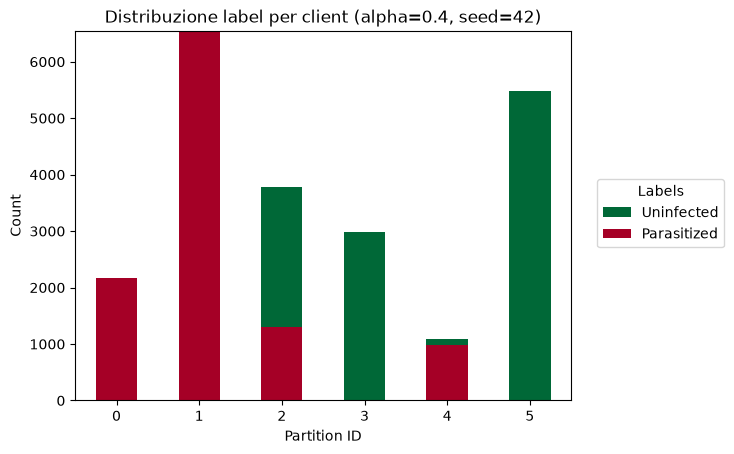

In [6]:
from flwr_datasets.visualization import plot_label_distributions

# Una figura per ogni alpha dello sweep (al primo seed), per vedere come cambia
# l'eterogeneita al variare del parametro di concentrazione.
# NB: e' una cella puramente diagnostica e ricarica il dataset per ogni alpha (get_fds
# svuota le cache al cambio di combinazione). Se da' problemi si puo' saltare: non serve
# al training della sezione 7.
_seed_viz = CONFIG.seeds[0]
for _alpha in CONFIG.alphas:
    try:
        fig, ax, df = plot_label_distributions(
            partitioner=get_partitioner(_alpha, _seed_viz),
            label_name="label",
            plot_type="bar",
            size_unit="absolute",
            partition_id_axis="x",
            legend=True,
            verbose_labels=True,
            title=f"Distribuzione label per client (alpha={_alpha}, seed={_seed_viz})",
        )
        plt.show()
    except Exception as _exc:  # noqa: BLE001 - cella diagnostica, non deve fermare il notebook
        print(f"alpha={_alpha}: grafico non disponibile ({type(_exc).__name__}: {_exc})")


## 4. Modello e funzioni di training/evaluation (PyTorch)

In [7]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Resize

NUM_CLASSES = 2  # Parasitized vs Uninfected


class Net(nn.Module):
    """CNN per crop di cellule malaria ridimensionati (RGB 32x32).

    Usa GroupNorm invece di BatchNorm: indipendente dalle statistiche di batch (adatto a
    batch piccoli/non-IID lato client) ed e' anche un requisito di Opacus, che rifiuta
    BatchNorm perche' mescola informazione tra campioni dello stesso batch e rende
    impossibile definire un gradiente per-campione.
    """

    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8, 32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, 64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.norm3 = nn.GroupNorm(8, 128)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.norm1(self.conv1(x))))
        x = self.pool(F.relu(self.norm2(self.conv2(x))))
        x = self.pool(F.relu(self.norm3(self.conv3(x))))
        x = self.global_pool(x).flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


IMAGE_SIZE = 32  # lato dell'immagine in input al modello
_resize = Resize((IMAGE_SIZE, IMAGE_SIZE))


def decode_to_tensors(hf_dataset) -> tuple[torch.Tensor, torch.Tensor]:
    """Decodifica UNA VOLTA SOLA l'intero dataset in due tensori in RAM (immagini gia'
    normalizzate + label), invece di decodificare i PNG a ogni accesso.

    Le operazioni sono identiche a `Compose([Resize, ToTensor, Normalize(0.5, 0.5)])`.
    """
    n = len(hf_dataset)
    images = torch.empty((n, 3, IMAGE_SIZE, IMAGE_SIZE), dtype=torch.float32)
    labels = torch.empty(n, dtype=torch.int64)
    for i, example in enumerate(hf_dataset):
        img = example["img"].convert("RGB")
        if img.size != (IMAGE_SIZE, IMAGE_SIZE):
            img = _resize(img)
        arr = torch.from_numpy(np.asarray(img, dtype=np.uint8)).permute(2, 0, 1)
        images[i] = arr.float().div_(255.0).sub_(0.5).div_(0.5)  # = ToTensor + Normalize(0.5, 0.5)
        labels[i] = example["label"]
    return images, labels


class DictTensorDataset(Dataset):
    """Dataset su tensori gia' in RAM che restituisce dizionari {"img", "label"}.

    Sostituisce il precedente iteratore `TensorBatches`. Il motivo del cambio e' che Opacus
    deve poter rimpiazzare il DataLoader con un `DPDataLoader` a **campionamento di Poisson**
    (requisito dell'analisi di privacy del Sampled Gaussian Mechanism), e per farlo gli serve
    un vero `torch.utils.data.DataLoader`.

    L'ottimizzazione che contava resta intatta: le immagini vengono decodificate una volta
    sola da `decode_to_tensors`, quindi qui `__getitem__` e' solo uno slice di tensore.
    """

    def __init__(self, images: torch.Tensor, labels: torch.Tensor):
        self.images = images
        self.labels = labels

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx):
        return {"img": self.images[idx], "label": self.labels[idx]}


# NB: _CLIENT_CACHE / _TESTSET_CACHE sono definite nella sezione 3 (get_fds le svuota al
# cambio di combinazione alpha/seed). In simulazione ogni client vive in un attore Ray
# riusato tra i round, quindi la decodifica avviene una sola volta per combinazione.


def load_client_data(partition_id: int, batch_size: int, alpha: float, seed: int):
    """Partizione di un client, divisa 80/20 in train/validation locali.

    Lo split di validation serve alla evaluation locale per round e, per i baseline locali,
    alla selezione del modello migliore (best-on-validation).
    """
    key = (alpha, seed, partition_id, batch_size)
    if key not in _CLIENT_CACHE:
        partition = get_fds(alpha, seed).load_partition(partition_id)
        partition_train_test = partition.train_test_split(test_size=0.2, seed=seed)
        train_x, train_y = decode_to_tensors(partition_train_test["train"])
        val_x, val_y = decode_to_tensors(partition_train_test["test"])
        _CLIENT_CACHE[key] = (
            DataLoader(DictTensorDataset(train_x, train_y), batch_size=batch_size, shuffle=True),
            DataLoader(DictTensorDataset(val_x, val_y), batch_size=batch_size, shuffle=False),
        )
    return _CLIENT_CACHE[key]


def load_centralized_testset(alpha: float, seed: int, batch_size: int = 128):
    """Test set centralizzato, mai visto dai client. Dipende dal seed (lo split e' seedato)."""
    key = (alpha, seed, batch_size)
    if key not in _TESTSET_CACHE:
        test_x, test_y = decode_to_tensors(get_fds(alpha, seed).load_split("test"))
        _TESTSET_CACHE[key] = DataLoader(
            DictTensorDataset(test_x, test_y), batch_size=batch_size, shuffle=False
        )
    return _TESTSET_CACHE[key]


def train(net, trainloader, epochs, lr, device, proximal_mu: float = 0.0,
          global_params=None, dp: dict | None = None, momentum: float = 0.9):
    """Training locale di un client.

    - `dp=None`: SGD normale (baseline non privata).
    - `dp` valorizzato: **DP-SGD record-level** via Opacus. Il `PrivacyEngine` clippa il
      gradiente di OGNI CAMPIONE a `max_grad_norm` e aggiunge rumore gaussiano prima
      dell'update, quindi i pesi rimandati al server sono gia' perturbati e il server non
      vede mai un update pulito (modello di minaccia honest-but-curious soddisfatto senza
      secure aggregation).

    `dp` e' un dict con: target_epsilon, target_delta, max_grad_norm, total_local_epochs.
    `total_local_epochs = num_rounds * local_epochs` e' il numero di epoche locali che il
    client eseguira' sull'INTERO training federato: passandolo a `make_private_with_epsilon`
    si ottiene un sigma calibrato sul budget totale, non su quello del singolo round.

    Termine prossimale di FedProx
    -----------------------------
    L'objective di FedProx e' h_k(w; w^t) = F_k(w) + (mu/2)*||w - w^t||^2, il cui gradiente
    e' grad F_k(w) + mu*(w - w^t). Qui il secondo pezzo viene applicato come step separato
    DOPO `optimizer.step()`, invece che sommato alla loss. Due motivi:

    1. **Correttezza sotto DP**: il `DPOptimizer` di Opacus ricostruisce `p.grad` dai
       gradienti per-campione (clippati + rumore), sovrascrivendolo. Un contributo scritto
       direttamente in `p.grad` sommando il termine alla loss verrebbe semplicemente perso.
    2. **Costo di privacy nullo**: il termine dipende solo dai pesi (locali e globali), che
       sono informazione pubblica, e non dai dati. Non deve quindi passare per il meccanismo
       DP ne' consumare budget.

    Rispetto alla formulazione accoppiata i due update coincidono a meno di un termine
    O(lr^2 * mu * grad): con lr=0.01 e mu=0.01 lo scarto relativo su uno step e' ~4e-4.

    Lo stesso schema si usa anche senza DP, cosi' baseline e run private ottimizzano
    esattamente lo stesso objective e restano confrontabili.

    NOTA su una correzione rispetto alla versione precedente: prima il termine veniva
    sommato alla loss come `(mu/2) * sum_i ||w_i - w_i^t||_2` usando `.norm(2)`, cioe' la
    somma delle NORME e non la norma al QUADRATO. Il gradiente che ne risulta e' un versore
    (w - w^t)/||w - w^t|| invece di (w - w^t), che non e' il termine prossimale di FedProx
    (Li et al., 2020). Qui e' implementato correttamente.
    """
    net.to(device)
    criterion = nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr, momentum=momentum)

    # Riferimento ai Parameter originali. Opacus avvolge `net` in un GradSampleModule ma
    # NON copia i tensori: aggiornarli tramite il DPOptimizer aggiorna anche `net`, che e'
    # l'oggetto di cui il client fara' `state_dict()` per rispondere al server.
    params = list(net.parameters())

    forward_module = net
    privacy_engine = None
    if dp is not None:
        from opacus import PrivacyEngine

        privacy_engine = PrivacyEngine(accountant="rdp")
        forward_module, optimizer, trainloader = privacy_engine.make_private_with_epsilon(
            module=net,
            optimizer=optimizer,
            data_loader=trainloader,
            target_epsilon=dp["target_epsilon"],
            target_delta=dp["target_delta"],
            epochs=dp["total_local_epochs"],
            max_grad_norm=dp["max_grad_norm"],
        )

    forward_module.train()
    running_loss, n_batches = 0.0, 0
    for _ in range(epochs):
        for batch in trainloader:
            images = batch["img"].to(device)
            labels = batch["label"].to(device)
            if labels.numel() == 0:
                continue  # il campionamento di Poisson di Opacus puo' produrre batch vuoti
            optimizer.zero_grad()
            loss = criterion(forward_module(images), labels)
            loss.backward()
            optimizer.step()

            if proximal_mu > 0.0 and global_params is not None:
                # step prossimale disaccoppiato: w <- w - lr * mu * (w - w_globali)
                with torch.no_grad():
                    for p, g in zip(params, global_params):
                        p.add_(p - g, alpha=-lr * proximal_mu)

            running_loss += loss.item()
            n_batches += 1

    avg_loss = running_loss / max(n_batches, 1)

    epsilon_round = None
    if privacy_engine is not None:
        # epsilon speso in QUESTO round: solo diagnostica. Il budget totale del client e'
        # dp["target_epsilon"], perche' sigma e' stato calibrato su total_local_epochs.
        epsilon_round = privacy_engine.get_epsilon(dp["target_delta"])
        if hasattr(forward_module, "remove_hooks"):
            forward_module.remove_hooks()

    return avg_loss, epsilon_round


def test(net, testloader, device):
    net.to(device)
    criterion = nn.CrossEntropyLoss()
    correct, loss = 0, 0.0
    net.eval()
    with torch.inference_mode():
        for batch in testloader:
            images = batch["img"].to(device)
            labels = batch["label"].to(device)
            outputs = net(images)
            loss += criterion(outputs, labels).item()
            correct += (torch.max(outputs.data, 1)[1] == labels).sum().item()
    accuracy = correct / len(testloader.dataset)
    return loss / len(testloader), accuracy


## 5. Privacy accounting: anteprima di sigma per client

Con DP-SGD record-level il `noise_multiplier` (sigma) viene calcolato **da Opacus stesso**
dentro `make_private_with_epsilon`, al momento del training. Questa cella e' solo
un'anteprima diagnostica che riproduce lo stesso calcolo con
`opacus.accountants.utils.get_noise_multiplier`, cosi' sai cosa aspettarti prima di lanciare
lo sweep.

Per ogni client l'accounting usa:

- `sample_rate = batch_size / n_campioni_di_training_del_client` — il campionamento e' sui
  **batch**, non sui client, e con `batch_size` piccolo rispetto a `n` si ottiene una forte
  **amplificazione da campionamento** (era completamente assente nella versione client-level,
  dove `sample_rate` valeva 1.0);
- `steps = num_rounds * local_epochs * ceil(n / batch_size)` — tutti gli step di SGD che quel
  client eseguira' nell'intero training federato.

Poiche' le partizioni Dirichlet hanno dimensioni diverse, **ogni client ottiene un sigma
diverso**: tutti spendono lo stesso epsilon, ciascuno calibrato sul proprio dataset.

### Come leggere il rapporto rumore/segnale

Ad ogni step il gradiente medio dei campioni clippati ha norma al piu' `max_grad_norm`,
mentre il rumore aggiunto ha norma attesa circa `sigma * max_grad_norm * sqrt(d) / batch_size`.
Il rapporto stampato e' quindi `sigma * sqrt(d) / batch_size`.

A differenza del caso client-level, **un rapporto > 1 qui non e' fatale**: il rumore e'
indipendente ad ogni step e si media su migliaia di step di SGD, mentre il segnale punta
in modo consistente nella stessa direzione. Abadi et al. (2016) raggiungono il 97% su MNIST
a epsilon = 8 proprio in questo regime. Serve comunque come campanello d'allarme: valori
nell'ordine delle centinaia indicano che a quell'epsilon il modello non imparera'.


In [8]:
import math

from opacus.accountants.utils import get_noise_multiplier


def client_train_sizes(cfg: ExperimentConfig, alpha: float, seed: int) -> list[int]:
    """Numero di campioni di TRAINING per ciascun client (dopo lo split locale 80/20)."""
    fds_ = get_fds(alpha, seed)
    return [int(len(fds_.load_partition(pid)) * 0.8) for pid in range(cfg.num_clients)]


def dp_plan(cfg: ExperimentConfig, n_train: int, target_epsilon: float):
    """(sample_rate, steps, sigma) per UN client con `n_train` campioni di training.

    Stesso schema di accounting che Opacus applichera' internamente in
    `make_private_with_epsilon`: unita' di privacy = singolo campione (record-level),
    Sampled Gaussian Mechanism con campionamento di Poisson sui batch.
    """
    sample_rate = cfg.batch_size / n_train
    steps = cfg.num_rounds * cfg.local_epochs * math.ceil(n_train / cfg.batch_size)
    sigma = get_noise_multiplier(
        target_epsilon=target_epsilon,
        target_delta=cfg.target_delta,
        sample_rate=sample_rate,
        steps=steps,
        accountant="rdp",
    )
    return sample_rate, steps, sigma


def dp_preview(cfg: ExperimentConfig, alpha: float, seed: int) -> None:
    sizes = client_train_sizes(cfg, alpha, seed)
    num_params = sum(p.numel() for p in Net().parameters())
    print(f"alpha={alpha}, seed={seed} | parametri del modello: {num_params:,}")
    print(f"campioni di training per client: {sizes}")
    print(f"delta = {cfg.target_delta}, max_grad_norm (C) = {cfg.max_grad_norm}, "
          f"batch = {cfg.batch_size}, local_epochs = {cfg.local_epochs}\n")
    if min(sizes) <= cfg.batch_size:
        print(f"!! ATTENZIONE: il client piu' piccolo ha {min(sizes)} campioni, <= batch_size "
              f"({cfg.batch_size}): sample_rate >= 1, l'accounting non e' valido. "
              f"Alza min_partition_size o abbassa batch_size.\n")
    for eps in cfg.target_epsilons:
        print(f"=== target epsilon = {eps}  (per client, sull'intero training) ===")
        for pid, n in enumerate(sizes):
            q, steps, sigma = dp_plan(cfg, n, eps)
            ratio = sigma * (num_params ** 0.5) / cfg.batch_size
            print(f"  client {pid}: n={n:6d}  q={q:.5f}  steps={steps:6d}  "
                  f"sigma={sigma:7.3f}  rumore/segnale per step ~ {ratio:7.1f}x")
        print()


if CONFIG.dp_enabled:
    # anteprima sulla prima combinazione dello sweep
    dp_preview(CONFIG, CONFIG.alphas[0], CONFIG.seeds[0])
else:
    print("DP disabilitato: nessun rumore verra' aggiunto. CONFIG.target_epsilons ignorato.")


alpha=0.4, seed=42 | parametri del modello: 102,082
campioni di training per client: [1732, 5236, 3020, 2388, 870, 4388]
delta = 1e-05, max_grad_norm (C) = 5.0, batch = 128, local_epochs = 1

=== target epsilon = 0.5  (per client, sull'intero training) ===
  client 0: n=  1732  q=0.07390  steps=  1400  sigma= 21.562  rumore/segnale per step ~    53.8x
  client 1: n=  5236  q=0.02445  steps=  4100  sigma= 12.188  rumore/segnale per step ~    30.4x
  client 2: n=  3020  q=0.04238  steps=  2400  sigma= 16.250  rumore/segnale per step ~    40.6x
  client 3: n=  2388  q=0.05360  steps=  1900  sigma= 18.125  rumore/segnale per step ~    45.2x
  client 4: n=   870  q=0.14713  steps=   700  sigma= 30.000  rumore/segnale per step ~    74.9x
  client 5: n=  4388  q=0.02917  steps=  3500  sigma= 13.438  rumore/segnale per step ~    33.5x

=== target epsilon = 1  (per client, sull'intero training) ===
  client 0: n=  1732  q=0.07390  steps=  1400  sigma= 11.328  rumore/segnale per step ~    28.3x


## 6. Flower ClientApp e ServerApp

- **ClientApp**: training/evaluation locale, condiviso da tutte le run. Riceve dal server,
  nel `ConfigRecord`, sia `proximal-mu` (iniettato automaticamente da `FedProx`) sia i
  parametri di privacy (`target-epsilon`, `target-delta`, `max-grad-norm`,
  `total-local-epochs`). Se `target-epsilon > 0` il training locale gira sotto DP-SGD.
- Non c'e' **nessun `mod` di clipping** lato Flower: con DP-SGD il clipping (per-campione) e
  l'iniezione di rumore avvengono entrambi dentro `train()`, gestiti da Opacus.
- **`global_evaluate`**: valutazione centralizzata sul test set globale, condivisa da tutte
  le run (non dipende da epsilon).


In [9]:
from flwr.app import ArrayRecord, ConfigRecord, Context, Message, MetricRecord, RecordDict
from flwr.clientapp import ClientApp

# Nessun mod di clipping lato Flower: con DP-SGD clipping e rumore sono dentro il training
# locale (Opacus), non nel percorso di aggregazione.
client_app = ClientApp()

# Ultima combinazione (alpha, seed) vista da questo attore in un messaggio di training.
# Serve da rete di sicurezza per la evaluation: `train_config` e `evaluate_config` sono due
# ConfigRecord distinti, e se il secondo non arrivasse popolato il client saprebbe comunque
# su quale partizione lavorare (train precede sempre evaluate nello stesso round).
_LAST_RUN_KEY: dict = {}


def _cfg_get(cfg, key, default=None):
    """ConfigRecord non espone .get(): questo lo emula."""
    try:
        return cfg[key]
    except KeyError:
        return default


@client_app.train()
def client_train(msg: Message, context: Context):
    model = Net()
    model.load_state_dict(msg.content["arrays"].to_torch_state_dict())
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Snapshot dei pesi globali ricevuti, usato dal termine prossimale di FedProx.
    global_params = [p.detach().clone() for p in model.parameters()]

    cfg = msg.content["config"]
    # alpha e seed arrivano dal server nel ConfigRecord: il client costruisce (o riusa dalla
    # cache) la propria partizione per quella combinazione, senza dipendere da global
    # condivise tra processi Ray.
    alpha = float(cfg["alpha"])
    seed = int(cfg["seed"])
    _LAST_RUN_KEY["alpha"], _LAST_RUN_KEY["seed"] = alpha, seed
    partition_id = context.node_config["partition-id"]
    trainloader, _ = load_client_data(partition_id, CONFIG.batch_size, alpha, seed)

    target_epsilon = float(cfg["target-epsilon"])
    dp = None
    if target_epsilon > 0:
        dp = {
            "target_epsilon": target_epsilon,
            "target_delta": float(cfg["target-delta"]),
            "max_grad_norm": float(cfg["max-grad-norm"]),
            "total_local_epochs": int(cfg["total-local-epochs"]),
        }

    train_loss, epsilon_round = train(
        model,
        trainloader,
        CONFIG.local_epochs,
        float(cfg["lr"]),
        device,
        proximal_mu=float(cfg["proximal-mu"]),
        global_params=global_params,
        dp=dp,
        # default 0.9 = il valore che era scritto a mano in train(): cosi' un config
        # prodotto da una versione precedente del notebook continua a funzionare.
        momentum=float(_cfg_get(cfg, "momentum", 0.9)),
    )

    metrics = {"train_loss": train_loss, "num-examples": len(trainloader.dataset)}
    if epsilon_round is not None:
        metrics["epsilon_round"] = epsilon_round

    content = RecordDict({
        "arrays": ArrayRecord(model.state_dict()),
        "metrics": MetricRecord(metrics),
    })
    return Message(content=content, reply_to=msg)


@client_app.evaluate()
def client_evaluate(msg: Message, context: Context):
    model = Net()
    model.load_state_dict(msg.content["arrays"].to_torch_state_dict())
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    cfg = msg.content["config"]
    # I messaggi di evaluate portano `evaluate_config`, non `train_config`: se per qualche
    # motivo alpha/seed non ci fossero, si ricade sull'ultima combinazione vista in training.
    alpha = _cfg_get(cfg, "alpha", _LAST_RUN_KEY.get("alpha"))
    seed = _cfg_get(cfg, "seed", _LAST_RUN_KEY.get("seed"))
    if alpha is None or seed is None:
        raise RuntimeError(
            "client_evaluate non sa su quale (alpha, seed) lavorare: ne' evaluate_config "
            "ne' un training precedente li hanno forniti."
        )
    alpha, seed = float(alpha), int(seed)
    partition_id = context.node_config["partition-id"]
    _, valloader = load_client_data(partition_id, CONFIG.batch_size, alpha, seed)

    eval_loss, eval_acc = test(model, valloader, device)

    content = RecordDict({
        "metrics": MetricRecord({
            "eval_loss": eval_loss,
            "eval_acc": eval_acc,
            "num-examples": len(valloader.dataset),
        }),
    })
    return Message(content=content, reply_to=msg)


In [10]:
from flwr.serverapp import Grid, ServerApp
from flwr.serverapp.strategy import FedProx

# NB: non si importano piu' DifferentialPrivacyServerSideFixedClipping /
# DifferentialPrivacyClientSideFixedClipping. Quei wrapper implementano DP *client-level*
# con rumore aggiunto lato server; qui la privacy e' record-level e interamente dentro il
# training locale del client (vedi sezione 4).


# Metriche della run in corso, accumulate round per round da global_evaluate. Le stesse
# metriche sono nel `Result` restituito da strategy.start(), ma quello arriva solo se la run
# finisce: tenendone una copia qui, anche una run interrotta a meta' conserva i round fatti.
_CURRENT_RUN_METRICS: list = []

# ---------------------------------------------------------------------------------
# Probabilita' predette, salvate round per round
# ---------------------------------------------------------------------------------
# Lo sweep NON calcola il Net Benefit: salva soltanto le probabilita' predette sul test
# set a ogni round. La DCA si calcola dopo, in baselines_e_analisi.ipynb, a partire da
# questi file. Cosi' la griglia di soglie, la classe considerata evento e la finestra di
# media restano tutte modificabili senza rifare una singola run.
#
# La utility del modello federato e' definita in Methodology come media sugli ultimi W
# round: servono quindi le predizioni di OGNI round, perche' i pesi finali salvati a fine
# run non bastano -- i modelli intermedi non esistono piu'.

@torch.inference_mode()
def evaluate_with_probs(net, loader, device):
    """Un solo passaggio sul test set: loss, accuracy, label grezze e P(label = 1).

    Restituisce di proposito la probabilita' della CLASSE 1 e le label GREZZE. Quale delle
    due classi sia l'evento clinico e' una scelta che appartiene all'analisi, non al
    training: tenendola fuori da qui, cambiarla non richiede di rifare nessuna run.
    """
    net.to(device).eval()
    criterion = nn.CrossEntropyLoss()
    loss, correct, n_batches = 0.0, 0, 0
    probs, labels = [], []
    for batch in loader:
        x = batch["img"].to(device)
        y = batch["label"].to(device)
        out = net(x)
        loss += criterion(out, y).item()
        correct += (out.argmax(1) == y).sum().item()
        probs.append(torch.softmax(out, dim=1)[:, 1].cpu())
        labels.append(y.cpu())
        n_batches += 1
    p1 = torch.cat(probs).numpy().astype(np.float32)
    y_raw = torch.cat(labels).numpy().astype(np.int8)
    return loss / max(n_batches, 1), correct / len(loader.dataset), y_raw, p1


def probs_path(alpha: float, seed: int, epsilon) -> str:
    """Un file binario per configurazione di privacy: float32 accodati, una riga per round.

    Formato grezzo e non CSV perche' sono ~5.500 valori per round: in binario sono 22 KB,
    in CSV sarebbero dieci volte tanto. Si rileggono con
        np.fromfile(path, dtype=np.float32).reshape(-1, n_test)
    e le righe incomplete di una run interrotta si riconoscono dal resto della divisione.
    """
    tag = "inf" if not np.isfinite(epsilon) else f"{epsilon:g}"
    return os.path.join(results_dir(alpha, seed), f"probs_eps{tag}.f32")


def labels_path(alpha: float, seed: int) -> str:
    """Le label del test set dipendono solo dal seed, quindi si salvano una volta sola."""
    return os.path.join(results_dir(alpha, seed), "test_labels.npy")


def make_global_evaluate(alpha: float, seed: int, epsilon=None):
    """Valutazione centralizzata sul test set globale della combinazione (alpha, seed).

    Oltre ad accuracy e loss salva su disco le probabilita' predette dal modello globale a
    quel round. Scrivere round per round invece che a fine run significa che anche una run
    interrotta lascia utilizzabili i round gia' completati.
    """
    eps_value = float("inf") if epsilon is None else float(epsilon)

    def global_evaluate(server_round: int, arrays: ArrayRecord) -> MetricRecord:
        model = Net()
        model.load_state_dict(arrays.to_torch_state_dict())
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        test_loader = load_centralized_testset(alpha, seed)
        test_loss, test_acc, y_raw, p1 = evaluate_with_probs(model, test_loader, device)

        os.makedirs(results_dir(alpha, seed), exist_ok=True)
        lp = labels_path(alpha, seed)
        if not os.path.exists(lp):
            np.save(lp, y_raw)          # le label dipendono solo dal seed: una volta sola
        with open(probs_path(alpha, seed, eps_value), "ab") as fb:
            fb.write(np.ascontiguousarray(p1, dtype=np.float32).tobytes())

        _CURRENT_RUN_METRICS.append(
            {"round": server_round, "accuracy": test_acc, "loss": test_loss}
        )

        return MetricRecord({"accuracy": test_acc, "loss": test_loss})

    return global_evaluate


### 6.1 Controllo: mappa delle classi

Lo sweep salva `P(indice = 1)` e le label grezze, quindi non deve decidere niente sulla
classe-evento. Questa cella serve solo a sapere **quale indice corrisponde a quale classe**,
informazione che poi useremo nel notebook di analisi per impostare `POSITIVE_LABEL`.

`imagefolder` assegna gli indici in ordine alfabetico, quindi ci si aspetta
`Parasitized = 0` e `Uninfected = 1`. L'evento clinico -- la cellula infetta, quella su cui
si interviene -- e' quindi l'indice 0.

In [11]:
_names = None
try:
    _split = get_fds(CONFIG.alphas[0], CONFIG.seeds[0]).load_split("test")
    _names = _split.features["label"].names
except Exception as _e:  # noqa: BLE001
    print("non sono riuscito a leggere i nomi delle classi:", _e)

if _names:
    print("mappa indice -> classe (assegnata da imagefolder in ordine alfabetico):")
    for _i, _n in enumerate(_names):
        print(f"  {_i} = {_n}")
    _y = np.asarray(_split["label"])
    for _i, _n in enumerate(_names):
        print(f"\nquota di '{_n}' nel test set: {(_y == _i).mean():.3f}  ({len(_y)} campioni)")
    print("\nLe probabilita' salvate dallo sweep sono P(indice = 1), cioe' P('"
          + _names[1] + "').")
    print("Quale classe sia l'EVENTO clinico su cui si decide di intervenire si sceglie "
          "nel\nnotebook di analisi (POSITIVE_LABEL), non qui: cambiarla non richiede di "
          "rifare run.")

mappa indice -> classe (assegnata da imagefolder in ordine alfabetico):
  0 = Parasitized
  1 = Uninfected

quota di 'Parasitized' nel test set: 0.500  (5512 campioni)

quota di 'Uninfected' nel test set: 0.500  (5512 campioni)

Le probabilita' salvate dallo sweep sono P(indice = 1), cioe' P('Uninfected').
Quale classe sia l'EVENTO clinico su cui si decide di intervenire si sceglie nel
notebook di analisi (POSITIVE_LABEL), non qui: cambiarla non richiede di rifare run.


## 7. Training (sweep completo)

Esegue lo sweep su **(seed, alpha, epsilon)**, annidati in quest'ordine. Ogni combinazione e'
una run federata completa da `num_rounds` round.

**Ripresa automatica**: con `CONFIG.skip_completed = True` le combinazioni gia' presenti su
disco (e completate) vengono saltate. Se lo sweep si interrompe di notte, basta rilanciare
questa cella: riparte da dove si era fermato, senza rifare nulla.

**Progresso e stima**: dopo ogni run vengono stampati durata, media e ETA sulle run rimanenti,
cosi' al mattino si capisce a colpo d'occhio a che punto e' arrivato.

**Salvataggio incrementale**: i risultati di ogni run vengono scritti subito in
`results/malaria/alpha_<alpha>_seed<seed>/` (pesi del modello, `training_history.csv`,
`final_results.csv`, `config.json`).

**Run interrotte**: agli epsilon piu' bassi il rumore puo' portare il training in un regime
degenere (loss `NaN`). L'eccezione viene catturata, i round gia' completati vengono salvati
con `completed = False`, e lo sweep prosegue con la combinazione successiva.

> **Attenzione ai risultati precedenti.** I file gia' presenti in `results/` sono stati
> prodotti con la DP *client-level*, epsilon 16-512, batch 32 e local_epochs 1. Non sono
> confrontabili con questi: sposta altrove la vecchia cartella prima di lanciare.


In [12]:
import json
import time

from flwr.simulation import run_simulation


def results_dir(alpha: float, seed: int) -> str:
    return os.path.join("results", "malaria", f"alpha_{alpha}_seed{seed}")


def run_training(alpha: float, seed: int, target_epsilon: float | None):
    """Esegue una run federata completa. target_epsilon=None => baseline senza DP.
    Ritorna (metriche per round, pesi finali del modello globale)."""
    set_seeds(seed)

    if target_epsilon is not None:
        sizes = client_train_sizes(CONFIG, alpha, seed)
        num_params = sum(p.numel() for p in Net().parameters())
        for pid, n in enumerate(sizes):
            q, steps, sigma = dp_plan(CONFIG, n, target_epsilon)
            ratio = sigma * (num_params ** 0.5) / CONFIG.batch_size
            print(f"    client {pid}: n={n} q={q:.5f} steps={steps} "
                  f"sigma={sigma:.3f} rumore/segnale~{ratio:.1f}x")

    server_app = ServerApp()
    holder = {}

    @server_app.main()
    def main(grid: Grid, context: Context) -> None:
        initial_arrays = ArrayRecord(Net().state_dict())
        strategy: FedProx = FedProx(
            proximal_mu=CONFIG.fedprox_mu,
            fraction_train=CONFIG.fraction_train,
            fraction_evaluate=CONFIG.fraction_evaluate,
            min_train_nodes=CONFIG.min_available_clients,
            min_evaluate_nodes=CONFIG.min_available_clients,
            min_available_nodes=CONFIG.min_available_clients,
        )
        # Nessun wrapper DP sulla strategia: la privacy e' dentro il training del client.
        # alpha/seed servono al client sia in training sia in evaluation, e i due
        # ConfigRecord sono distinti: vanno messi in entrambi.
        eval_config = ConfigRecord({"alpha": float(alpha), "seed": int(seed)})
        start_kwargs = dict(
            grid=grid,
            initial_arrays=initial_arrays,
            num_rounds=CONFIG.num_rounds,
            train_config=ConfigRecord({
                "lr": CONFIG.learning_rate,
                "momentum": float(CONFIG.momentum),
                # letta da CONFIG qui dentro, non da una costante: cosi' override_config
                # la vede. La strategia FedProx inietta gia' "proximal-mu", ma metterla
                # esplicitamente rende il notebook indipendente dalla versione di Flower.
                "proximal-mu": float(CONFIG.fedprox_mu),
                "alpha": float(alpha),
                "seed": int(seed),
                "target-epsilon": float(target_epsilon) if target_epsilon is not None else -1.0,
                "target-delta": float(CONFIG.target_delta),
                "max-grad-norm": float(CONFIG.max_grad_norm),
                # epoche locali totali del client sull'intero training federato: serve a
                # Opacus per calibrare sigma sul budget TOTALE e non su quello di un round
                "total-local-epochs": int(CONFIG.num_rounds * CONFIG.local_epochs),
            }),
            evaluate_fn=make_global_evaluate(alpha, seed, target_epsilon),
        )
        try:
            res = strategy.start(**start_kwargs, evaluate_config=eval_config)
        except TypeError:
            # versioni di Flower che non espongono `evaluate_config`: il client ricade sulla
            # combinazione memorizzata durante il training (vedi _LAST_RUN_KEY).
            print("    nota: questa versione di Flower non accetta evaluate_config, "
                  "il client usa il fallback")
            res = strategy.start(**start_kwargs)
        holder["result"] = res

    _CURRENT_RUN_METRICS.clear()
    error = None
    try:
        run_simulation(
            server_app=server_app,
            client_app=client_app,
            num_supernodes=CONFIG.num_clients,
            backend_config={"client_resources": CONFIG.client_resources},
        )
    except Exception as exc:  # noqa: BLE001 - si prosegue con la combinazione successiva
        error = exc
        print(f"    !! run interrotta: {type(exc).__name__}: {exc}")
        print(f"       round completati: {max(len(_CURRENT_RUN_METRICS) - 1, 0)}")

    if error is None and "result" not in holder:
        error = RuntimeError("run_simulation terminata senza produrre un risultato")
        print(f"    !! {error}")

    epsilon_value = target_epsilon if target_epsilon is not None else float("inf")

    if error is None:
        res = holder["result"]
        rounds_ = sorted(res.evaluate_metrics_serverapp.keys())
        round_df = pd.DataFrame({
            "round": rounds_,
            "accuracy": [res.evaluate_metrics_serverapp[r]["accuracy"] for r in rounds_],
            "loss": [res.evaluate_metrics_serverapp[r]["loss"] for r in rounds_],
            "epsilon": epsilon_value,
            "alpha": alpha,
            "seed": seed,
            "completed": True,
        })
        return round_df, res.arrays

    round_df = pd.DataFrame(_CURRENT_RUN_METRICS)
    if not round_df.empty:
        round_df["epsilon"] = epsilon_value
        round_df["alpha"] = alpha
        round_df["seed"] = seed
        round_df["completed"] = False
    return round_df, None


SUMMARY_LAST_N = 10  # su quanti round finali calcolare media e deviazione standard


def summarize_results(history: pd.DataFrame, last_n: int = SUMMARY_LAST_N) -> pd.DataFrame:
    """Tabella riassuntiva, una riga per (alpha, seed, epsilon).

    Oltre ai valori dell'ultimo round riporta media/std dell'accuracy sugli ultimi `last_n`
    round e il massimo raggiunto. Motivo: con epsilon nella zona di transizione il modello
    globale non converge ma oscilla (il rumore DP viene rigenerato a ogni step, quindi i pesi
    fanno una specie di random walk) e l'accuracy del solo ultimo round e' poco affidabile.
    La media sugli ultimi round e' molto piu' stabile, la std quantifica l'instabilita'.
    """
    group_cols = [c for c in ["alpha", "seed", "epsilon"] if c in history.columns]
    rows = []
    for keys, group in history.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        group = group.sort_values("round")
        tail = group["accuracy"].tail(last_n)
        last = group.iloc[-1]
        best = group.loc[group["accuracy"].idxmax()]
        row = dict(zip(group_cols, keys))
        row.update({
            "round": int(last["round"]),
            "accuracy": last["accuracy"],
            "loss": last["loss"],
            f"acc_media_ultimi{last_n}": tail.mean(),
            f"acc_std_ultimi{last_n}": tail.std(),
            "acc_max": best["accuracy"],
            "acc_max_round": int(best["round"]),
            "completed": bool(group["completed"].iloc[-1]) if "completed" in group.columns else True,
        })
        rows.append(row)
    return pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)


def save_config_snapshot(out_dir: str, alpha: float, seed: int) -> None:
    """Snapshot della CONFIG usata per questa combinazione."""
    os.makedirs(out_dir, exist_ok=True)
    snapshot = asdict(CONFIG)
    snapshot["alpha_of_this_run"] = alpha
    snapshot["seed_of_this_run"] = seed
    with open(os.path.join(out_dir, "config.json"), "w") as f:
        json.dump(snapshot, f, indent=2)


def save_run(out_dir: str, epsilon, arrays, round_df: pd.DataFrame) -> None:
    """Salva pesi + storico della run appena conclusa, unendo a quanto gia' su disco."""
    os.makedirs(out_dir, exist_ok=True)
    if arrays is not None:
        eps_label = "no_dp" if epsilon is None else f"epsilon_{epsilon}"
        model_path = os.path.join(out_dir, f"{eps_label}.pt")
        torch.save(arrays.to_torch_state_dict(), model_path)
        print(f"    salvato: {model_path}")
    else:
        print("    nessun modello finale (run interrotta)")

    if round_df.empty:
        return
    path = os.path.join(out_dir, "training_history.csv")
    if os.path.exists(path):
        previous = pd.read_csv(path)
        previous = previous[previous["epsilon"] != round_df["epsilon"].iloc[0]]
        history = pd.concat([previous, round_df], ignore_index=True)
    else:
        history = round_df
    history.to_csv(path, index=False)
    summarize_results(history).to_csv(os.path.join(out_dir, "final_results.csv"), index=False)


def already_done(alpha: float, seed: int, epsilon) -> bool:
    """True se questa combinazione e' gia' su disco e completata (per la ripresa)."""
    path = os.path.join(results_dir(alpha, seed), "training_history.csv")
    if not os.path.exists(path):
        return False
    df = pd.read_csv(path)
    value = float("inf") if epsilon is None else float(epsilon)
    sub = df[df["epsilon"] == value]
    if sub.empty:
        return False
    return bool(sub["completed"].iloc[-1]) if "completed" in sub.columns else True


# ---------------------------------------------------------------------------------
# Sweep: seed (esterno) -> alpha -> epsilon (interno).
# ---------------------------------------------------------------------------------
# Mettere RUN_SWEEP = False per (ri)definire soltanto le funzioni di questa cella senza
# lanciare lo sweep: serve alla cella di diagnostica qui sotto, che ha bisogno di
# `run_training` ma non deve far partire 96 run.
RUN_SWEEP = True

_eps_list = ([None] if CONFIG.run_baseline else []) + \
            (list(CONFIG.target_epsilons) if CONFIG.dp_enabled else [])
JOBS = ([(s, a, e) for s in CONFIG.seeds for a in CONFIG.alphas for e in _eps_list]
        if RUN_SWEEP else [])

if not RUN_SWEEP:
    print("RUN_SWEEP = False: sweep non lanciato, le funzioni sopra sono definite.")
print(f"run totali pianificate: {len(JOBS)}")
if CONFIG.max_hours > 0:
    print(f"budget di tempo: {CONFIG.max_hours} h (poi lo sweep si ferma in modo pulito)")
print()

_sweep_t0 = time.time()
_durations = []
_stopped_early = False
for _i, (_seed, _alpha, _eps) in enumerate(JOBS, start=1):
    if CONFIG.max_hours > 0 and (time.time() - _sweep_t0) / 3600 >= CONFIG.max_hours:
        print(f"\nbudget di {CONFIG.max_hours} h esaurito: mi fermo a {_i - 1}/{len(JOBS)} run.")
        print("rilancia questa cella per riprendere da dove si e' fermato.")
        _stopped_early = True
        break
    _label = f"seed={_seed} alpha={_alpha} epsilon={_eps if _eps is not None else 'inf (no DP)'}"
    if CONFIG.skip_completed and already_done(_alpha, _seed, _eps):
        print(f"[{_i}/{len(JOBS)}] {_label} -- gia' fatto, salto")
        continue

    print(f"\n[{_i}/{len(JOBS)}] {_label}")
    _t0 = time.time()
    _out = results_dir(_alpha, _seed)
    try:
        save_config_snapshot(_out, _alpha, _seed)
        _round_df, _arrays = run_training(_alpha, _seed, _eps)
        save_run(_out, _eps, _arrays, _round_df)
    except Exception as _exc:  # noqa: BLE001 - una combinazione rotta non deve fermare lo sweep
        print(f"    !! combinazione fallita: {type(_exc).__name__}: {_exc}")
        print("       si prosegue con la successiva")

    _durations.append(time.time() - _t0)
    _mean = sum(_durations) / len(_durations)
    _left = len(JOBS) - _i
    print(f"    durata {_durations[-1] / 60:.1f} min | media {_mean / 60:.1f} min | "
          f"ETA ~{_left * _mean / 3600:.1f} h ({_left} run rimanenti)")

if not _stopped_early:
    print("\nsweep terminato: tutte le combinazioni pianificate sono state percorse.")



            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
09/21/2026 02:12:30:WARNING:DEPRECATED FEATURE: The `run_simulation` function is deprecated and will be removed in a future version of Flower. Please use `flwr run` in the CLI instead to run your simulation. Refer to the Flower Tutorials for more details: https://flower.ai/docs/framework/tutorial-quickstart-pytorch.html

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
09/21/2026 02:12:30:DEBUG:backend_config: {'client_resources': {'num_cpus': 2, 'num_gpus': 0.0}}
09/21/2026 02:12:30:DEBUG:Asyncio event loop already running.
INFO :      Starting FedProx strategy:
INFO :      	├── Number of rounds: 100
INFO :      	├── ArrayRecord (0.39 MB)
INFO :      	├── ConfigRecord (train): {'lr': 0.03, 'momentum': 0.0, 'proximal-mu': 0.01, 'alpha': 0.4, 'seed': 42, 'target-epsilon': -1.0, 'target-delta': 1e

run totali pianificate: 18


[1/18] seed=42 alpha=0.4 epsilon=inf (no DP)


/tmp/ipykernel_1167/3687080460.py:59: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  arr = torch.from_numpy(np.asarray(img, dtype=np.uint8)).permute(2, 0, 1)
2026-09-21 02:12:30,895	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
/home/ubuntu/Projects/master_thesis_2/.venv/lib/python3.14/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and t

    salvato: results/malaria/alpha_0.4_seed42/no_dp.pt
    durata 11.5 min | media 11.5 min | ETA ~3.3 h (17 run rimanenti)

[2/18] seed=42 alpha=0.4 epsilon=0.5
    client 0: n=1732 q=0.07390 steps=1400 sigma=21.562 rumore/segnale~53.8x
    client 1: n=5236 q=0.02445 steps=4100 sigma=12.188 rumore/segnale~30.4x
    client 2: n=3020 q=0.04238 steps=2400 sigma=16.250 rumore/segnale~40.6x
    client 3: n=2388 q=0.05360 steps=1900 sigma=18.125 rumore/segnale~45.2x
    client 4: n=870 q=0.14713 steps=700 sigma=30.000 rumore/segnale~74.9x
    client 5: n=4388 q=0.02917 steps=3500 sigma=13.438 rumore/segnale~33.5x



            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting FedProx strategy:
INFO :      	├── Number of rounds: 100
INFO :      	├── ArrayRecord (0.39 MB)
INFO :      	├── ConfigRecord (train): {'lr': 0.03, 'momentum': 0.0, 'proximal-mu': 0.01, 'alpha': 0.4, 'seed': 42, 'target-epsilon': 0.5, 'target-delta': 1e-05, 'max-grad-norm': 5.0, 'total-local-epochs': 100}
INFO :      	├── ConfigRecord (evaluate): {'alpha': 0.4, 'seed': 42}
INFO :      	├──> FedProx settings:
INFO :      	│	└── Proximal mu: 0.01
INFO :      	├──> Sampling:
INFO :      	│	├──Fraction: train (1.00) | evaluate ( 1.00)
INFO :      	│	├──Minimum nodes: train (2) | evaluate (2)
INFO :      	│	└──Minimum available nodes: 2
INFO :      	└──> Keys in records:
INFO :      		├── Weighted by: 'num-examples'
INFO :      		├── ArrayRecord key: 'arrays'
INFO :      		└── ConfigRecord key: 'config'
INFO :      
INFO :      Initial global evaluat

...

    salvato: results/malaria/alpha_0.4_seed44/epsilon_4.pt
    durata 17.6 min | media 15.6 min | ETA ~0.3 h (1 run rimanenti)

[18/18] seed=44 alpha=0.4 epsilon=8
    client 0: n=1061 q=0.12064 steps=900 sigma=2.451 rumore/segnale~6.1x
    client 1: n=2016 q=0.06349 steps=1600 sigma=1.794 rumore/segnale~4.5x
    client 2: n=6395 q=0.02002 steps=5000 sigma=1.140 rumore/segnale~2.8x
    client 3: n=905 q=0.14144 steps=800 sigma=2.688 rumore/segnale~6.7x
    client 4: n=5484 q=0.02334 steps=4300 sigma=1.204 rumore/segnale~3.0x



            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting FedProx strategy:
INFO :      	├── Number of rounds: 100
INFO :      	├── ArrayRecord (0.39 MB)
INFO :      	├── ConfigRecord (train): {'lr': 0.03, 'momentum': 0.0, 'proximal-mu': 0.01, 'alpha': 0.4, 'seed': 44, 'target-epsilon': 8.0, 'target-delta': 1e-05, 'max-grad-norm': 5.0, 'total-local-epochs': 100}
INFO :      	├── ConfigRecord (evaluate): {'alpha': 0.4, 'seed': 44}
INFO :      	├──> FedProx settings:
INFO :      	│	└── Proximal mu: 0.01
INFO :      	├──> Sampling:
INFO :      	│	├──Fraction: train (1.00) | evaluate ( 1.00)
INFO :      	│	├──Minimum nodes: train (2) | evaluate (2)
INFO :      	│	└──Minimum available nodes: 2
INFO :      	└──> Keys in records:
INFO :      		├── Weighted by: 'num-examples'
INFO :      		├── ArrayRecord key: 'arrays'
INFO :      		└── ConfigRecord key: 'config'
INFO :      


    client 5: n=1773 q=0.07219 steps=1400 sigma=1.892 rumore/segnale~4.7x


INFO :      Initial global evaluation results: {'accuracy': 0.5181422351233672, 'loss': 0.693336005915295}
INFO :      
INFO :      [ROUND 1/100]
INFO :      configure_train: Sampled 6 nodes (out of 6)
(ClientAppActor pid=72717) /tmp/ipykernel_1167/3687080460.py:59: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
(ClientAppActor pid=72719) /home/ubuntu/Projects/master_thesis_2/.venv/lib/python3.14/site-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain on

    salvato: results/malaria/alpha_0.4_seed44/epsilon_8.pt
    durata 18.1 min | media 15.7 min | ETA ~0.0 h (0 run rimanenti)

sweep terminato: tutte le combinazioni pianificate sono state percorse.


## 7.1 Diagnostica: perche' alpha <= 0.5 fallisce anche senza DP

Dai risultati del primo sweep, a `alpha = 0.2` (entrambi i seed) e a `alpha = 0.5, seed = 42`
il modello globale finisce con **loss = 0.693 = ln 2** e accuracy esattamente 0.500 con
deviazione standard 0.000, *anche a epsilon = infinito*, cioe' con la privacy disattivata.
Una loss di ln 2 su due classi bilanciate significa che il modello emette probabilita' 0.5 su
ogni campione: non ha imparato nulla. Il fallimento non e' causato dal rumore DP.

Ci sono tre ipotesi in gioco, e queste cinque run le separano:

1. **Clipping e non rumore.** A `alpha = 1, seed = 42` il gap rispetto al baseline e' costante
   (circa -0.33) da epsilon=1 a epsilon=32, mentre sigma cambia di un ordine di grandezza.
   L'unica cosa identica a tutti gli epsilon e' il clipping per-campione a `max_grad_norm = 1`.
2. **Round insufficienti.** A `alpha = 0.5, seed = 43` il baseline ha toccato `acc_max = 0.875`
   **al round 50**, l'ultimo: stava ancora salendo. La media sugli ultimi 10 round riporta
   0.637 per una run arrivata a 0.875.
3. **Termine prossimale troppo debole.** `fedprox_mu = 0.01` e' vicino a FedAvg; Li et al.
   (2020) spazzolano mu in {0.001, 0.01, 0.1, 1}.

**Come eseguirla**: nella cella dello sweep mettere `RUN_SWEEP = False` ed eseguirla (definisce
`run_training` senza lanciare nulla), poi eseguire la cella qui sotto. Le run sono ordinate
dalla piu' rapida alla piu' lenta: le prime tre sono da 50 round e rispondono gia' a due
domande su tre. Nulla viene scritto in `results/malaria/`: l'output va in
`results/diagnostics/`, quindi lo sweep vero non viene toccato ne' inquinato.

In [13]:
# from contextlib import contextmanager


# @contextmanager
# def override_config(**kw):
#     """Modifica temporaneamente CONFIG e ripristina i valori originali all'uscita,
#     anche se la run solleva un'eccezione."""
#     old = {k: getattr(CONFIG, k) for k in kw}
#     for k, v in kw.items():
#         setattr(CONFIG, k, v)
#     try:
#         yield
#     finally:
#         for k, v in old.items():
#             setattr(CONFIG, k, v)


# # (nome, alpha, seed, epsilon, override su CONFIG, riferimento dallo sweep, cosa decide)
# DIAGNOSTICS = [
#     ("D1-clipping", 1.0, 42, 1000.0, {}, 0.632,
#      "a epsilon=1000 sigma e' trascurabile ma il clipping a C=1 resta attivo. "
#      "Se resta ~0.63 il collo di bottiglia e' il CLIPPING; se risale verso ~0.95 e' il RUMORE"),
#     ("D2-clip-C5", 1.0, 42, 32.0, {"max_grad_norm": 5.0}, 0.632,
#      "controprova: stesso epsilon, clipping 5x piu' lasco. Attenzione: con C piu' grande "
#      "cresce anche il rumore assoluto (sigma moltiplica C), quindi un miglioramento e' "
#      "prova forte a favore del clipping, un peggioramento non e' prova contraria"),
#     ("D3-mu-0.1", 0.5, 42, None, {"fedprox_mu": 0.1}, 0.500,
#      "termine prossimale 10x piu' forte sulla combinazione morta, senza DP"),
#     ("D4-rounds-s42", 0.5, 42, None, {"num_rounds": 200}, 0.500,
#      "a 200 round esce dal collasso o e' morta davvero? (~4x il tempo di una run normale)"),
#     ("D5-rounds-s43", 0.5, 43, None, {"num_rounds": 200}, 0.637,
#      "questa a 50 round stava ancora salendo (max 0.875 al round 50): dove arriva? "
#      "(~4x il tempo di una run normale)"),
# ]

# DIAG_DIR = os.path.join("results", "diagnostics")
# DIAG_CSV = os.path.join(DIAG_DIR, "diagnostics.csv")
# os.makedirs(DIAG_DIR, exist_ok=True)

# _done = set()
# if os.path.exists(DIAG_CSV):
#     _done = set(pd.read_csv(DIAG_CSV)["nome"].unique())
#     print(f"gia' su disco, verranno saltate: {sorted(_done)}\n")

# _rows = []
# for _name, _alpha, _seed, _eps, _ovr, _ref, _why in DIAGNOSTICS:
#     if _name in _done:
#         print(f"[{_name}] gia' fatto, salto")
#         continue
#     print(f"\n=== {_name} | alpha={_alpha} seed={_seed} "
#           f"epsilon={_eps if _eps is not None else 'inf (no DP)'} "
#           f"{_ovr if _ovr else ''}")
#     print(f"    {_why}")
#     _t0 = time.time()
#     try:
#         with override_config(**_ovr):
#             _rounds = CONFIG.num_rounds
#             _df, _ = run_training(_alpha, _seed, _eps)
#     except Exception as _exc:  # noqa: BLE001 - una diagnostica rotta non ferma le altre
#         print(f"    !! fallita: {type(_exc).__name__}: {_exc}")
#         continue
#     if _df.empty:
#         print("    !! nessuna metrica prodotta")
#         continue

#     _last10 = _df.sort_values("round").tail(10)["accuracy"]
#     _imax = _df["accuracy"].idxmax()
#     _row = {
#         "nome": _name, "alpha": _alpha, "seed": _seed,
#         "epsilon": _eps if _eps is not None else float("inf"),
#         "override": str(_ovr), "round_totali": _rounds,
#         "acc_media_ultimi10": _last10.mean(),
#         "acc_std_ultimi10": _last10.std(ddof=0),
#         "acc_max": _df.loc[_imax, "accuracy"],
#         "acc_max_round": int(_df.loc[_imax, "round"]),
#         "loss_finale": _df.sort_values("round")["loss"].iloc[-1],
#         "riferimento_sweep": _ref,
#         "durata_min": (time.time() - _t0) / 60,
#     }
#     _row["delta_vs_riferimento"] = _row["acc_media_ultimi10"] - _ref
#     _row["ancora_in_salita"] = _row["acc_max_round"] >= _rounds - 5
#     _rows.append(_row)

#     _out = pd.DataFrame(_rows)
#     if os.path.exists(DIAG_CSV):
#         _out = pd.concat([pd.read_csv(DIAG_CSV), _out], ignore_index=True)
#         _out = _out.drop_duplicates(subset="nome", keep="last")
#     _out.to_csv(DIAG_CSV, index=False)

#     print(f"    -> media ultimi10 = {_row['acc_media_ultimi10']:.3f} "
#           f"(riferimento {_ref:.3f}, delta {_row['delta_vs_riferimento']:+.3f}) | "
#           f"max {_row['acc_max']:.3f} al round {_row['acc_max_round']}/{_rounds} | "
#           f"loss {_row['loss_finale']:.3f} | {_row['durata_min']:.1f} min")
#     if abs(_row["loss_finale"] - 0.6931) < 0.01:
#         print("       loss ~ ln 2: il modello predice ancora 50/50 su tutto")
#     if _row["ancora_in_salita"]:
#         print("       il massimo e' negli ultimi round: NON ha ancora convergito")

# print("\n" + "=" * 78)
# if os.path.exists(DIAG_CSV):
#     _final = pd.read_csv(DIAG_CSV)
#     _cols = ["nome", "round_totali", "acc_media_ultimi10", "acc_max", "acc_max_round",
#              "loss_finale", "riferimento_sweep", "delta_vs_riferimento", "ancora_in_salita"]
#     print(_final[_cols].to_string(index=False))
#     print(f"\nsalvato in {DIAG_CSV}")
# print("""
# Come leggerlo:
#   D1  delta ~ 0      -> il limite e' il CLIPPING, non il rumore: rifare lo sweep con
#                         max_grad_norm piu' alto (o clipping adattivo)
#       delta ~ +0.3   -> e' il rumore, e a alpha=1/seed42 la run era semplicemente sfortunata
#   D3  delta ~ +0.4   -> fedprox_mu = 0.01 era troppo debole: portarlo a 0.1
#   D4  delta ~ 0 e loss ancora ~ln 2 -> alpha=0.5/seed42 e' collasso vero, non lentezza
#   D5  ancora_in_salita = True -> 50 round non bastano a alpha <= 0.5: alzare num_rounds
#                         (e rivedere la finestra di media in Methodology)
# """)

### 7.2 Verifica: il termine prossimale di FedProx viene davvero applicato?

Nel primo sweep, portare `fedprox_mu` da 0.01 a 0.1 ha prodotto risultati **bit-identici**
(differenza massima su accuracy e loss esattamente 0.000e+00 su tutti i 51 round). Due
ipotesi: o il valore non arriva al training loop, o il termine prossimale non viene mai
applicato. Se fosse la seconda, quello che il documento chiama FedProx starebbe girando come
FedAvg puro.

Le due prove qui sotto separano le ipotesi.

- **Prova A** chiama `train()` direttamente, senza Flower e senza Ray, due volte sugli stessi
  dati e con lo stesso seed, cambiando solo `mu`. Se i pesi finali coincidono, il problema e'
  dentro `train()`. Se differiscono, `train()` funziona e il problema e' nel passaggio del
  valore. Gira in pochi secondi e non tocca nulla su disco.
- **Prova B** instrumenta `client_train` per stampare il `proximal-mu` che il client riceve
  davvero dal server, e va eseguita prima di una simulazione breve.

Nota: la Prova A va fatta **senza DP** (`use_dp=False`, il default). Con Opacus attivo ogni
run aggiunge rumore casuale, quindi due esecuzioni differirebbero comunque e il test non
distinguerebbe piu' nulla.

In [14]:
# import copy


# def _flat_state(net):
#     """Pesi del modello in un unico vettore, per confrontare due run."""
#     return torch.cat([v.detach().float().flatten() for v in net.state_dict().values()])


# def check_proximal(mus=(0.0, 0.01, 0.1, 0.5), alpha=None, seed=42,
#                    partition_id=0, epochs=1, use_dp=False):
#     """PROVA A -- il termine prossimale cambia i pesi finali?

#     Esegue `train()` una volta per ogni valore di mu, partendo sempre dagli stessi pesi e
#     con gli stessi seed, quindi l'UNICA differenza fra le run e' mu. Come nel client vero,
#     `global_params` e' una copia dei pesi iniziali: a inizio training w - w_globali = 0 e il
#     termine prossimale e' nullo, poi cresce man mano che i pesi locali si allontanano.
#     """
#     alpha = CONFIG.alphas[0] if alpha is None else alpha
#     trainloader, _ = load_client_data(partition_id, CONFIG.batch_size, alpha, seed)
#     device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

#     set_seeds(0)
#     w0 = copy.deepcopy(Net().state_dict())

#     finals = {}
#     for mu in mus:
#         set_seeds(0)  # stessa inizializzazione, stesso ordine dei batch
#         net = Net()
#         net.load_state_dict(copy.deepcopy(w0))
#         net.to(device)
#         global_params = [p.detach().clone() for p in net.parameters()]
#         dp = None
#         if use_dp:
#             dp = {"target_epsilon": 1000.0, "target_delta": CONFIG.target_delta,
#                   "max_grad_norm": CONFIG.max_grad_norm, "total_local_epochs": epochs}
#         train(net, trainloader, epochs, CONFIG.learning_rate, device,
#               proximal_mu=mu, global_params=global_params, dp=dp)
#         finals[mu] = _flat_state(net).cpu()
#         print(f"  mu={mu:<6} fatto")

#     base = finals[mus[0]]
#     scale = base.abs().max().item()
#     print(f"\nconfronto rispetto a mu={mus[0]} (scala dei pesi: {scale:.4f})")
#     moved = False
#     for mu in mus[1:]:
#         d = (finals[mu] - base).abs().max().item()
#         rel = d / max(scale, 1e-12)
#         flag = "IDENTICI" if d == 0.0 else f"diversi (rel {rel:.2e})"
#         print(f"  mu={mu:<6} max|delta pesi| = {d:.3e}   {flag}")
#         if d > 0.0:
#             moved = True

#     print("\n" + "-" * 70)
#     if moved:
#         print("ESITO: train() applica il termine prossimale. Il valore di mu cambia i pesi,")
#         print("       quindi il problema sta nel PASSAGGIO di mu dal server al client.")
#         print("       -> esegui la Prova B.")
#     else:
#         print("ESITO: train() NON applica il termine prossimale: mu e' ininfluente.")
#         print("       Controlla il blocco `if proximal_mu > 0.0 and global_params is not None`")
#         print("       dentro train(): il ramo non viene mai eseguito, oppure `params` non")
#         print("       punta ai tensori che il client poi serializza con state_dict().")
#         print("       In questo caso quello che gira e' FedAvg, non FedProx.")
#     return finals


# print("PROVA A -- effetto di mu sui pesi finali (senza DP)")
# _ = check_proximal()

# print("\n\n" + "=" * 70)
# print("""PROVA B -- quale proximal-mu riceve davvero il client?

# Il `train_config` costruito a mano in run_training NON contiene la chiave `proximal-mu`:
# la inietta la strategia FedProx di Flower. Per vedere il valore che arriva davvero,
# incolla questa riga in `client_train` (cella 16) subito dopo `cfg = msg.content["config"]`:

#     print(f"[client] proximal-mu ricevuto = {_cfg_get(cfg, 'proximal-mu', 'CHIAVE ASSENTE')}")

# poi lancia una simulazione corta, per esempio abbassando CONFIG.num_rounds a 2 con
# override_config e chiamando run_training(CONFIG.alphas[0], 42, None).

# Come leggere l'output:
#   stampa 0.01 quando CONFIG.fedprox_mu = 0.1  -> l'override non arriva alla strategia:
#       la FedProx va costruita DOPO aver cambiato CONFIG (dentro run_training lo e' gia',
#       quindi in tal caso la run diagnostica era stata lanciata fuori da override_config)
#   stampa 'CHIAVE ASSENTE'                     -> Flower non inietta la chiave in questa
#       versione: aggiungila a mano al train_config in run_training,
#       "proximal-mu": float(CONFIG.fedprox_mu)
#   stampa il valore giusto                     -> mu arriva, e il sospetto torna su train()
# """)

### 7.3 Diagnostica: l'ottimizzatore fa divergere i client?

D4 e D5 hanno mostrato che a `alpha = 0.5`, con impostazioni identiche, la seed 43 arriva a
**0.951** in 200 round mentre la seed 42 resta a **0.500** e non supera mai il caso, nemmeno
una volta. Non e' lentezza: e' morte. E soprattutto non e' una proprieta' di alpha=0.5, perche'
se lo fosse fallirebbero entrambe le estrazioni.

La traiettoria della seed 42 dice cosa succede: nei round 2-16 la loss esplode fino a 3.59,
poi si blocca su ln 2 e non si muove piu'. Divergenza, e a seguire collasso nel predittore
costante.

Il sospetto e' l'ottimizzatore. Con momentum $m$ il passo effettivo a regime e' circa
$lr / (1 - m)$: con `lr = 0.03` e `m = 0.9` sono **~0.3**, molto aggressivo per una CNN.
Sotto label skew severo un client quasi mono-classe produce gradienti grandi e coerenti, il
momentum li accumula, i pesi divergono.

Le quattro run qui sotto variano solo l'ottimizzatore, a parita' di tutto il resto
(alpha=0.5, seed 42, nessun DP, 100 round). Se anche una sola porta la seed 42 a imparare,
la causa e' quella e il prossimo sweep va rifatto con l'ottimizzatore corretto.

| | lr | momentum | passo effettivo |
|---|---|---|---|
| riferimento (D4) | 0.03 | 0.9 | ~0.30 |
| E1 | 0.01 | 0.9 | ~0.10 |
| E2 | 0.003 | 0.9 | ~0.03 |
| E3 | 0.03 | 0.0 | 0.03 |
| E4 | 0.01 | 0.0 | 0.01 |

E3 ed E4 servono a separare le due cause: se basta togliere il momentum, il problema e'
l'accumulo; se serve anche abbassare lr, il passo era troppo grande di suo. Circa 45 minuti
in tutto. Come per la 7.2, esegui prima la cella dello sweep con `RUN_SWEEP = False`.

In [15]:
# from contextlib import contextmanager

# # Definiti anche nella cella 7.1: ripetuti qui per rendere questa cella autosufficiente,
# # cosi' puo' essere eseguita senza aver prima eseguito le diagnostiche 7.1.
# DIAG_DIR = os.path.join("results", "diagnostics")
# os.makedirs(DIAG_DIR, exist_ok=True)

# if "override_config" not in globals():
#     @contextmanager
#     def override_config(**kw):
#         """Modifica temporaneamente CONFIG e ripristina i valori originali all'uscita,
#         anche se la run solleva un'eccezione."""
#         old = {k: getattr(CONFIG, k) for k in kw}
#         for k, v in kw.items():
#             setattr(CONFIG, k, v)
#         try:
#             yield
#         finally:
#             for k, v in old.items():
#                 setattr(CONFIG, k, v)


# OPTIM_TRIALS = [
#     # (nome, lr, momentum)
#     ("E1-lr0.01-m0.9",  0.01,  0.9),
#     ("E2-lr0.003-m0.9", 0.003, 0.9),
#     ("E3-lr0.03-m0.0",  0.03,  0.0),
#     ("E4-lr0.01-m0.0",  0.01,  0.0),
# ]

# OPTIM_ALPHA, OPTIM_SEED, OPTIM_ROUNDS = 0.5, 42, 100
# OPTIM_CSV = os.path.join(DIAG_DIR, "optimizer.csv")
# LN2 = float(np.log(2))

# _done_o = set()
# if os.path.exists(OPTIM_CSV):
#     _done_o = set(pd.read_csv(OPTIM_CSV)["nome"].unique())
#     print(f"gia' su disco, verranno saltate: {sorted(_done_o)}\n")

# _rows_o = []
# for _name, _lr, _mom in OPTIM_TRIALS:
#     if _name in _done_o:
#         print(f"[{_name}] gia' fatto, salto")
#         continue
#     print(f"\n=== {_name} | lr={_lr} momentum={_mom} "
#           f"(passo effettivo ~{_lr / max(1 - _mom, 1e-9):.3f}) | "
#           f"alpha={OPTIM_ALPHA} seed={OPTIM_SEED} no DP | {OPTIM_ROUNDS} round")
#     _t0 = time.time()
#     try:
#         with override_config(learning_rate=_lr, momentum=_mom, num_rounds=OPTIM_ROUNDS):
#             _df, _ = run_training(OPTIM_ALPHA, OPTIM_SEED, None)
#     except Exception as _exc:  # noqa: BLE001
#         print(f"    !! fallita: {type(_exc).__name__}: {_exc}")
#         continue
#     if _df.empty:
#         print("    !! nessuna metrica prodotta")
#         continue

#     _s = _df.sort_values("round")
#     _last10 = _s.tail(10)["accuracy"]
#     _imax = _df["accuracy"].idxmax()
#     # Il segnale che conta non e' l'accuracy finale ma se la rete si e' MOSSA: a quale
#     # round la loss si stacca stabilmente da ln 2, e quanto e' esplosa all'inizio.
#     _off = _s[(_s["loss"] - LN2).abs() > 0.01]
#     _escape = int(_off["round"].iloc[0]) if len(_off) else None
#     _row = {
#         "nome": _name, "lr": _lr, "momentum": _mom,
#         "passo_effettivo": _lr / max(1 - _mom, 1e-9),
#         "round_totali": OPTIM_ROUNDS,
#         "acc_media_ultimi10": _last10.mean(),
#         "acc_max": _df.loc[_imax, "accuracy"],
#         "acc_max_round": int(_df.loc[_imax, "round"]),
#         "loss_finale": _s["loss"].iloc[-1],
#         "loss_max": _s["loss"].max(),
#         "loss_max_round": int(_s.loc[_s["loss"].idxmax(), "round"]),
#         "primo_round_fuori_da_ln2": _escape,
#         "ha_imparato": bool(_df["accuracy"].max() > 0.55),
#         "durata_min": (time.time() - _t0) / 60,
#     }
#     _rows_o.append(_row)

#     _out = pd.DataFrame(_rows_o)
#     if os.path.exists(OPTIM_CSV):
#         _out = pd.concat([pd.read_csv(OPTIM_CSV), _out], ignore_index=True)
#         _out = _out.drop_duplicates(subset="nome", keep="last")
#     _out.to_csv(OPTIM_CSV, index=False)

#     print(f"    -> media ultimi10 = {_row['acc_media_ultimi10']:.3f} | "
#           f"max {_row['acc_max']:.3f} al round {_row['acc_max_round']} | "
#           f"loss finale {_row['loss_finale']:.4f} | {_row['durata_min']:.1f} min")
#     print(f"       loss massima {_row['loss_max']:.2f} al round {_row['loss_max_round']} "
#           f"(quanto e' divergita all'inizio)")
#     if _row["ha_imparato"]:
#         print(f"       HA IMPARATO: uscita da ln 2 al round {_escape}")
#     else:
#         print("       ancora bloccata sul predittore costante")

# print("\n" + "=" * 78)
# if os.path.exists(OPTIM_CSV):
#     _f = pd.read_csv(OPTIM_CSV)
#     print(_f[["nome", "lr", "momentum", "passo_effettivo", "acc_media_ultimi10", "acc_max",
#               "loss_max", "primo_round_fuori_da_ln2", "ha_imparato"]].to_string(index=False))
#     _ok = _f[_f["ha_imparato"]]
#     print()
#     if len(_ok):
#         _best = _ok.loc[_ok["acc_media_ultimi10"].idxmax()]
#         print(f"ESITO: la causa era l'ottimizzatore. La configurazione migliore fra quelle "
#               f"provate e'\n       {_best['nome']} (lr={_best['lr']}, momentum={_best['momentum']}), "
#               f"che arriva a {_best['acc_media_ultimi10']:.3f}.")
#         print("       Il prossimo sweep va rifatto con questi valori. Da rivedere anche "
#               "num_rounds:\n       senza i round sprecati a divergere la convergenza "
#               "dovrebbe arrivare prima.")
#         if (_f["momentum"] == 0.0).any() and _ok["momentum"].min() == 0.0 \
#            and not (_ok["momentum"] > 0).any():
#             print("       Nota: hanno funzionato solo le run senza momentum -> il colpevole "
#                   "e' l'accumulo,\n       non il learning rate di per se'.")
#     else:
#         print("ESITO: nessuna configurazione dell'ottimizzatore recupera la seed 42.")
#         print("       Il problema non e' il passo. Prossimi sospetti, in ordine: "
#               "inizializzazione dei pesi,\n       ReLU morte (controllare quante attivazioni "
#               "sono sempre a zero), normalizzazione\n       delle immagini, e la "
#               "possibilita' che questa specifica partizione sia degenere\n       "
#               "(un client con una sola classe e nessun campione dell'altra).")

## 8. Risultati

Rilegge dal disco tutte le combinazioni dello sweep e costruisce:

- `history_all` — lo storico completo round per round, con colonne `alpha`, `seed`, `epsilon`;
- `summary_all` — una riga per (alpha, seed, epsilon), con accuracy dell'ultimo round,
  `acc_media_ultimi10` / `acc_std_ultimi10` e `acc_max`;
- `summary_mean` — la media sui seed, cioe' la tabella che finisce in tesi: per ogni
  (alpha, epsilon) la media di `acc_media_ultimi10` sui draw Dirichlet indipendenti.

I grafici mostrano una curva accuracy-vs-epsilon per ogni alpha (mediata sui seed) e le curve
di convergenza per round. La colonna `completed` segnala le run interrotte, le cui metriche
non sono confrontabili con le altre.


In [16]:
import glob as _glob

# Rilegge tutto dal disco: funziona anche in un kernel nuovo, senza rifare il training.
_frames = []
for _path in _glob.glob(os.path.join("results", "malaria", "alpha_*_seed*", "training_history.csv")):
    _df = pd.read_csv(_path)
    _frames.append(_df)

if not _frames:
    raise SystemExit("nessun risultato trovato in results/malaria/ - lancia prima la sezione 7")

history_all = pd.concat(_frames, ignore_index=True)
summary_all = summarize_results(history_all)

# Media sui seed: e' la tabella che va in tesi (media sui draw Dirichlet indipendenti).
_acc_col = f"acc_media_ultimi{SUMMARY_LAST_N}"
summary_mean = (
    summary_all[summary_all["completed"]]
    .groupby(["alpha", "epsilon"])
    .agg(acc_media=(_acc_col, "mean"),
         acc_std_tra_seed=(_acc_col, "std"),
         n_seed=(_acc_col, "size"))
    .reset_index()
    .sort_values(["alpha", "epsilon"])
)

print(f"combinazioni trovate: {len(summary_all)}  "
      f"(interrotte: {(~summary_all['completed']).sum()})")
summary_mean


combinazioni trovate: 108  (interrotte: 0)


,alpha,epsilon,acc_media,acc_std_tra_seed,n_seed
0,0.2,0.5,0.568560,0.020003,3
1,0.2,1.0,0.615463,0.015902,3
2,0.2,2.0,0.648035,0.013408,3
3,0.2,4.0,0.659077,0.011664,3
4,0.2,8.0,0.671740,0.019881,3
5,0.2,inf,0.765596,0.172744,3
6,0.3,0.5,0.524413,0.038158,3
7,0.3,1.0,0.587694,0.020414,3
8,0.3,2.0,0.639181,0.036370,3
9,0.3,4.0,0.662367,0.067296,3


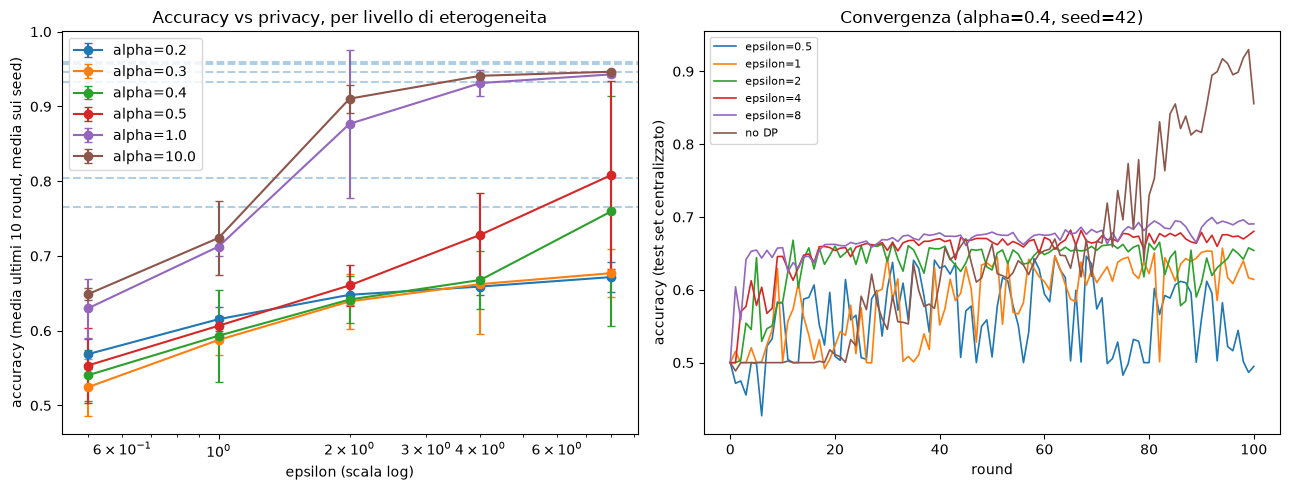

,alpha,seed,epsilon,round,accuracy,loss,acc_media_ultimi10,acc_std_ultimi10,acc_max,acc_max_round,completed
0,0.2,42,0.5,100,0.501814,1.241477,0.548458,0.035056,0.611756,22,True
1,0.2,42,1.0,100,0.591255,0.736474,0.618160,0.020704,0.646045,91,True
2,0.2,42,2.0,100,0.652939,0.633098,0.642326,0.016557,0.671626,41,True
3,0.2,42,4.0,100,0.646952,0.669748,0.648694,0.012196,0.667816,81,True
4,0.2,42,8.0,100,0.673258,0.719846,0.675381,0.002671,0.679608,99,True
...,...,...,...,...,...,...,...,...,...,...,...
103,10.0,44,1.0,100,0.696118,0.747832,0.690276,0.003751,0.696118,100,True
104,10.0,44,2.0,100,0.907475,0.308712,0.903592,0.006445,0.911284,98,True
105,10.0,44,4.0,100,0.941219,0.234805,0.940766,0.000722,0.942126,92,True
106,10.0,44,8.0,100,0.945392,0.234791,0.945283,0.000647,0.946843,97,True


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) accuracy vs epsilon, una curva per alpha (media sui seed)
for _alpha, _g in summary_mean.groupby("alpha"):
    _finite = _g[np.isfinite(_g["epsilon"])].sort_values("epsilon")
    if _finite.empty:
        continue
    axes[0].errorbar(_finite["epsilon"], _finite["acc_media"],
                     yerr=_finite["acc_std_tra_seed"], marker="o", capsize=3,
                     label=f"alpha={_alpha}")
    _base = _g[~np.isfinite(_g["epsilon"])]
    if not _base.empty:
        axes[0].axhline(_base["acc_media"].iloc[0], linestyle="--", alpha=0.35)

axes[0].set_xscale("log")
axes[0].set_xlabel("epsilon (scala log)")
axes[0].set_ylabel(f"accuracy (media ultimi {SUMMARY_LAST_N} round, media sui seed)")
axes[0].set_title("Accuracy vs privacy, per livello di eterogeneita")
axes[0].legend()

# (b) curve di convergenza del primo seed, alla alpha piu' eterogenea
_alpha_min = min(CONFIG.alphas)
_seed0 = CONFIG.seeds[0]
_conv = history_all[(history_all["alpha"] == _alpha_min) & (history_all["seed"] == _seed0)]
for _eps, _g in _conv.groupby("epsilon"):
    _label = "no DP" if not np.isfinite(_eps) else f"epsilon={_eps:g}"
    _g = _g.sort_values("round")
    axes[1].plot(_g["round"], _g["accuracy"], label=_label, linewidth=1.2)
axes[1].set_xlabel("round")
axes[1].set_ylabel("accuracy (test set centralizzato)")
axes[1].set_title(f"Convergenza (alpha={_alpha_min}, seed={_seed0})")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

summary_all


## 9. Esportazione per la tesi

I file per-combinazione sono gia' stati scritti in modo incrementale dalla sezione 7, dentro
`results/malaria/alpha_<alpha>_seed<seed>/` (pesi `.pt`, `training_history.csv`,
`final_results.csv`, `config.json`).

Questa cella scrive in piu' due file aggregati sull'intero sweep, comodi da citare in tesi e
da passare allo script della Decision Curve Analysis:

- `results/malaria/summary_all.csv` — una riga per (alpha, seed, epsilon);
- `results/malaria/summary_mean.csv` — media sui seed, una riga per (alpha, epsilon).

I pesi dei modelli restano nelle cartelle per-combinazione: `calculate_dca.py` li rilegge da
li' per calcolare il Net Benefit.


In [18]:
_root = os.path.join("results", "malaria")
os.makedirs(_root, exist_ok=True)

_summary_all_path = os.path.join(_root, "summary_all.csv")
summary_all.to_csv(_summary_all_path, index=False)
print(f"salvato: {_summary_all_path}  ({len(summary_all)} righe)")

_summary_mean_path = os.path.join(_root, "summary_mean.csv")
summary_mean.to_csv(_summary_mean_path, index=False)
print(f"salvato: {_summary_mean_path}  ({len(summary_mean)} righe)")

_history_path = os.path.join(_root, "history_all.csv")
history_all.to_csv(_history_path, index=False)
print(f"salvato: {_history_path}  ({len(history_all)} righe)")

_incomplete = summary_all[~summary_all["completed"]]
if not _incomplete.empty:
    print(f"\n{len(_incomplete)} run interrotte (metriche NON confrontabili con le altre):")
    print(_incomplete[["alpha", "seed", "epsilon", "round"]].to_string(index=False))

_modelli = len(_glob.glob(os.path.join(_root, "alpha_*_seed*", "*.pt")))
print(f"\nmodelli salvati su disco: {_modelli}")


salvato: results/malaria/summary_all.csv  (108 righe)
salvato: results/malaria/summary_mean.csv  (36 righe)
salvato: results/malaria/history_all.csv  (10908 righe)

modelli salvati su disco: 108
